# SR-PDS simulation - full HPC run

Production-quality results for the dissertation. Run this on icelake
after `main_quick.ipynb` has verified the pipeline.

**Configuration**

- All 8 DGPs, all 7 estimators
- Headline: n=500, n_reps=500 for everything except sr_pds_cf which
  uses n_reps=100 (cross-fit is 5x more expensive per rep and the
  point of having it is to show match against same-data SR-PDS,
  which doesn't need MC SE 0.02 - 0.05 is plenty)
- Trajectory: n in {30, 40, ..., 100, 200, 500, 1000, 2000, 5000} at
  n_reps=25 (no sr_pds_cf in the trajectory - it lives at n=500 only)
- Large-n extension: n=10,000 on DGPs 1, 6, 7, 8 and n=50,000 on DGPs
  6, 7, 8, both at n_reps=25
- Seed-robustness: 10 PySR seeds on one DGP-6 dataset at n=500

**Expected wall-clock on a 76-core icelake-himem node:** ~4-8 hours
total. PySR is the bottleneck; everything else parallelises well.

**SLURM advice:**

```
#SBATCH -partition=icelake-himem
#SBATCH -nodes=1 -cpus-per-task=76
#SBATCH -time=10:00:00 -mem=256G
export JULIA_NUM_THREADS=4
export OMP_NUM_THREADS=4
```

The `JULIA_NUM_THREADS=4` lets each PySR fit use 4 cores while joblib
runs roughly 19 reps in parallel. If you see OOM errors, drop N_JOBS
below.


## 1. Setup

In [1]:
import os
import sys
import pickle
import warnings
import datetime
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '.')

from dgp import DGP_REGISTRY
from estimators import ESTIMATOR_REGISTRY, SR_PDS_LOG, PYSR_CONFIG
from simulation import run_all, run_simulation, seed_robustness_check
from evaluate import (evaluate_all, summary_table, print_summary,
                      evaluate_recovery)
from plots import (plot_bias, plot_coverage, plot_rmse_heatmap,
                   plot_summary_panel, plot_distributions,
                   plot_recovery_heatmap, plot_coefficient_recovery,
                   plot_n_trajectory, plot_recovery_vs_n)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

N_HEADLINE     = 500
P              = 50
S              = 6
BETA0          = 0.5
N_REPS_MAIN    = 500    # headline
N_REPS_CF      = 100    # cross-fit (5x slower per rep)
N_REPS_TRAJ    = 25     # trajectory + large-n
N_REPS_SEEDS   = 10     # PySR seeds for the seed-robustness check
N_JOBS         = 16     # outer parallelism (conservative; ~76/4 = 19 ceiling)
RESULTS_DIR    = '../results_full'

os.makedirs(RESULTS_DIR, exist_ok=True)
DGP_KEYS = list(DGP_REGISTRY.keys())
EST_KEYS = list(ESTIMATOR_REGISTRY.keys())

print(f"DGPs ({len(DGP_KEYS)}):       {DGP_KEYS}")
print(f"Estimators ({len(EST_KEYS)}): {EST_KEYS}")
print(f"Headline n={N_HEADLINE}, n_reps={N_REPS_MAIN} (sr_pds_cf at {N_REPS_CF})")
print(f"PySR: maxsize={PYSR_CONFIG['maxsize']}, "
      f"niter={PYSR_CONFIG['niterations']}, "
      f"parsimony=({PYSR_CONFIG['parsimony_y']}, {PYSR_CONFIG['parsimony_d']})")

DGPs (8):       ['dgp1', 'dgp2', 'dgp3', 'dgp4', 'dgp5', 'dgp6', 'dgp7', 'dgp8']
Estimators (7): ['full_ols', 'pds_lasso', 'dml_lasso', 'dml_rf', 'dml_nn', 'sr_pds', 'sr_pds_cf']
Headline n=500, n_reps=500 (sr_pds_cf at 100)
PySR: maxsize=30, niter=40, parsimony=(0.005, 0.01)


## 2. Headline simulation

All 8 DGPs x 7 estimators at n=500. SR-PDS-CF reps are reduced to 100
via `reps_overrides`. Expected runtime ~2-3 hours on 76 cores.

In [2]:
SR_PDS_LOG.clear()

t0 = time.time()
combined = run_all(
    dgp_registry       = DGP_REGISTRY,
    estimator_registry = ESTIMATOR_REGISTRY,
    dgp_keys           = DGP_KEYS,
    estimator_keys     = EST_KEYS,
    n                  = N_HEADLINE,
    p                  = P,
    s                  = S,
    beta0              = BETA0,
    n_reps             = N_REPS_MAIN,
    n_jobs             = N_JOBS,
    save_dir           = RESULTS_DIR,
    reps_overrides     = {'sr_pds_cf': N_REPS_CF},
)
print(f"\nHeadline complete in {(time.time()-t0)/60:.1f} min")

combined.to_pickle(f'{RESULTS_DIR}/headline.pkl')
with open(f'{RESULTS_DIR}/sr_pds_log_headline.pkl', 'wb') as f:
    pickle.dump(list(SR_PDS_LOG), f)


[  0.0 min]  Linear x Full OLS  (n_jobs=16, n_reps=500)



[  0.1 min]  Linear x PDS-LASSO  (n_jobs=16, n_reps=500)



[  0.1 min]  Linear x DML-LASSO  (n_jobs=16, n_reps=500)



[  0.1 min]  Linear x DML-RF  (n_jobs=16, n_reps=500)



[530.5 min]  Linear x DML-NN  (n_jobs=16, n_reps=500)


...


[2172.3 min]  Weak NL conf. (dummies) x DML-RF  (n_jobs=16, n_reps=500)



[2200.9 min]  Weak NL conf. (dummies) x DML-NN  (n_jobs=16, n_reps=500)



[2201.8 min]  Weak NL conf. (dummies) x SR-PDS  (n_jobs=1, n_reps=500)



[2256.3 min]  Weak NL conf. (dummies) x SR-PDS (CF)  (n_jobs=1, n_reps=100)



All results saved to ../results_full/all_results.csv
SR-PDS log (4800 entries) saved to ../results_full/sr_pds_log.pkl

Total time: 2307.0 min

Headline complete in 2307.0 min


## 3. Headline metrics and plots

In [3]:
all_metrics = evaluate_all(combined, beta0=BETA0)
all_metrics.to_csv(f'{RESULTS_DIR}/headline_metrics.csv', index=False)
print_summary(all_metrics, BETA0)


True ATE: 0.5

BIAS
------------------------------------------------------------
                         DML-LASSO  DML-NN  DML-RF  Full OLS  PDS-LASSO  SR-PDS  SR-PDS (CF)
DGP                                                                                         
Interactions               -0.0057  0.0967 -0.0123   -0.0078    -0.0276 -0.0067       0.0099
Linear                      0.0013  0.0885 -0.0113    0.0010     0.0001  0.0000      -0.0006
Mixed nonlinear             0.0264  0.1653  0.0069    0.0287     0.0128 -0.0145       0.0121
NL + linear conf.           0.0200  0.2049 -0.1248    0.0287     0.0140 -0.0168       0.0505
NL + mild NL conf.          1.2147  1.1334  1.3196    1.2003     1.1726 -0.0253       0.0244
NL + severe NL conf.        1.6311  1.5677  1.4433    1.5985     1.5890  0.1103       0.2991
Quadratic                   0.0004  0.0378 -0.0016   -0.0004    -0.0158 -0.0097       0.0345
Weak NL conf. (dummies)     0.7822  0.7902  0.6231    0.7702     0.7363 -0.0129  

  Saved: ../figures/bias.png


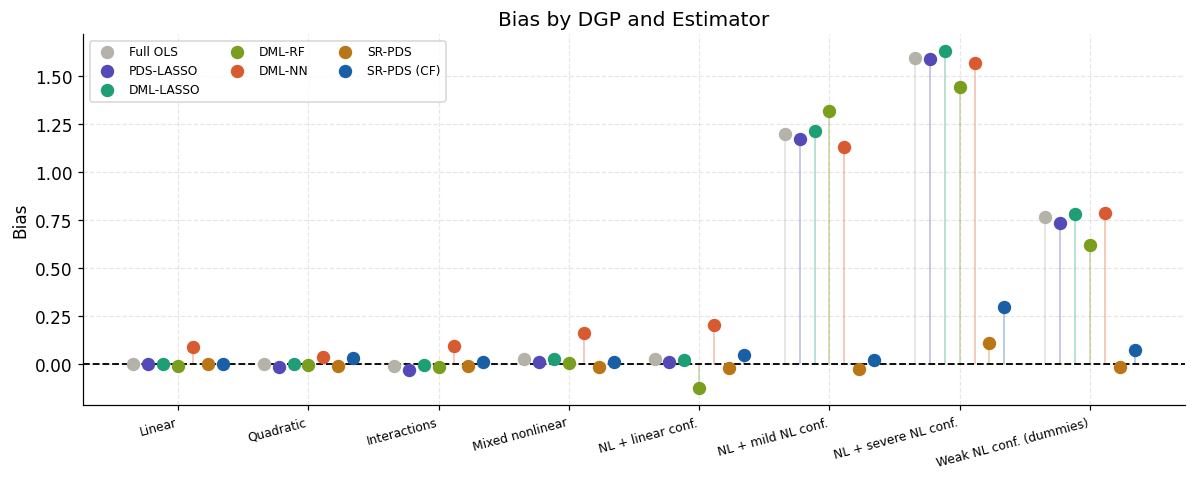

  Saved: ../figures/coverage.png


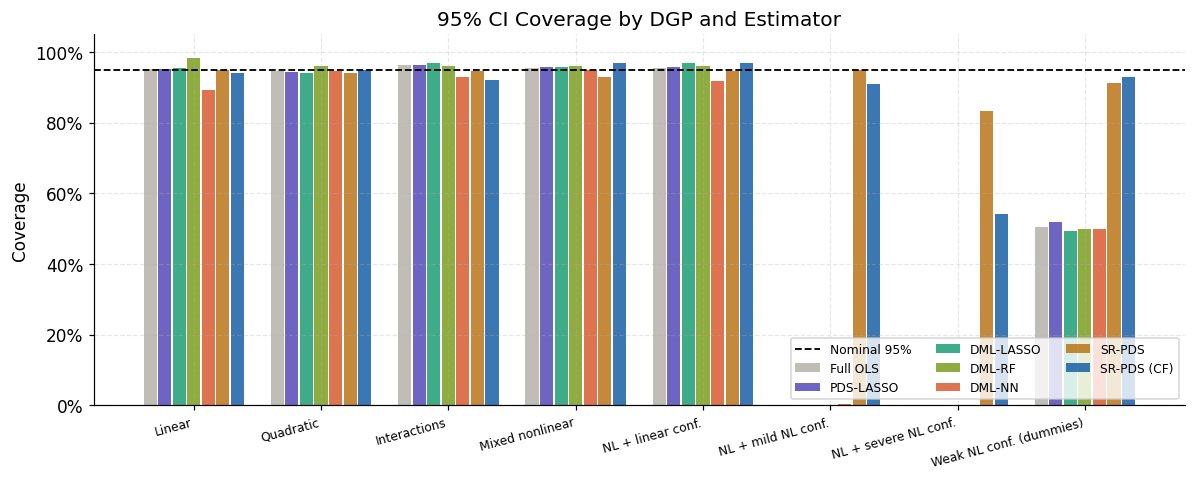

  Saved: ../figures/rmse_heatmap.png


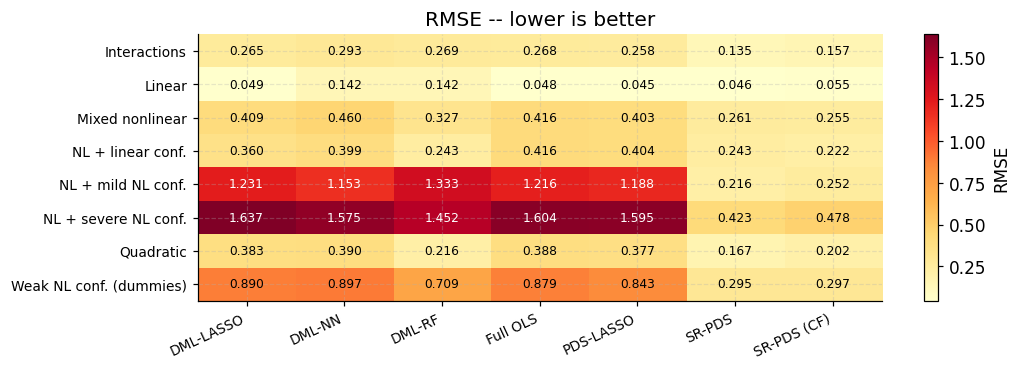

  Saved: ../figures/summary_panel.png


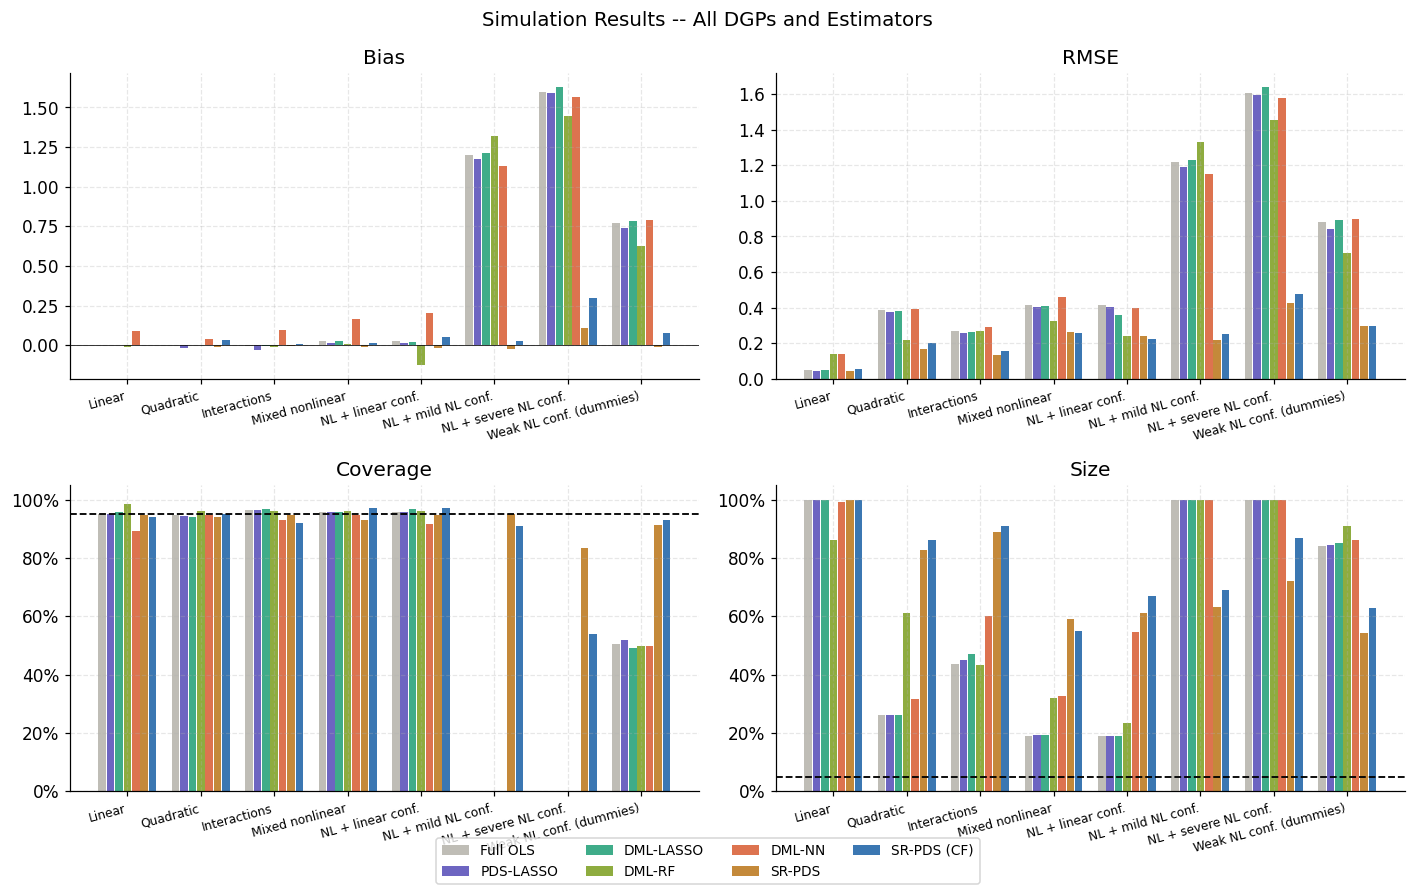

  Saved: ../figures/dist_dgp1.png


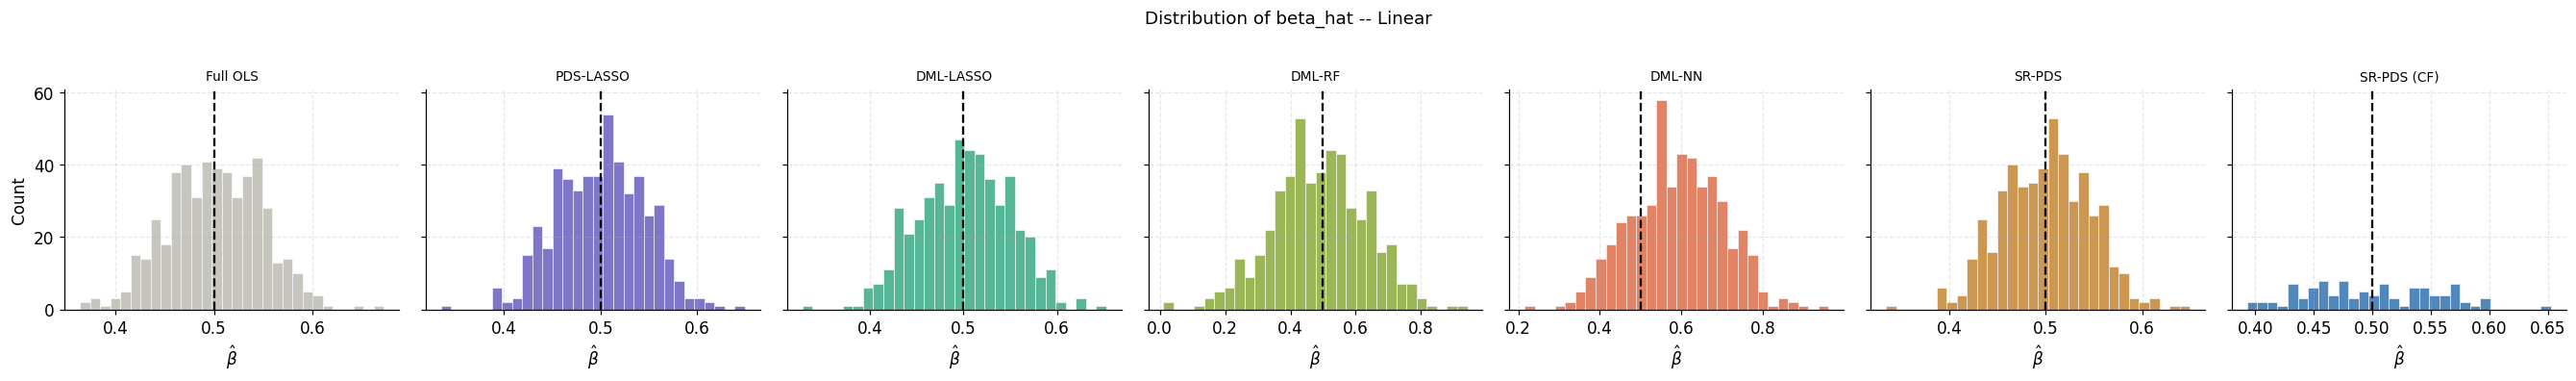

  Saved: ../figures/dist_dgp2.png


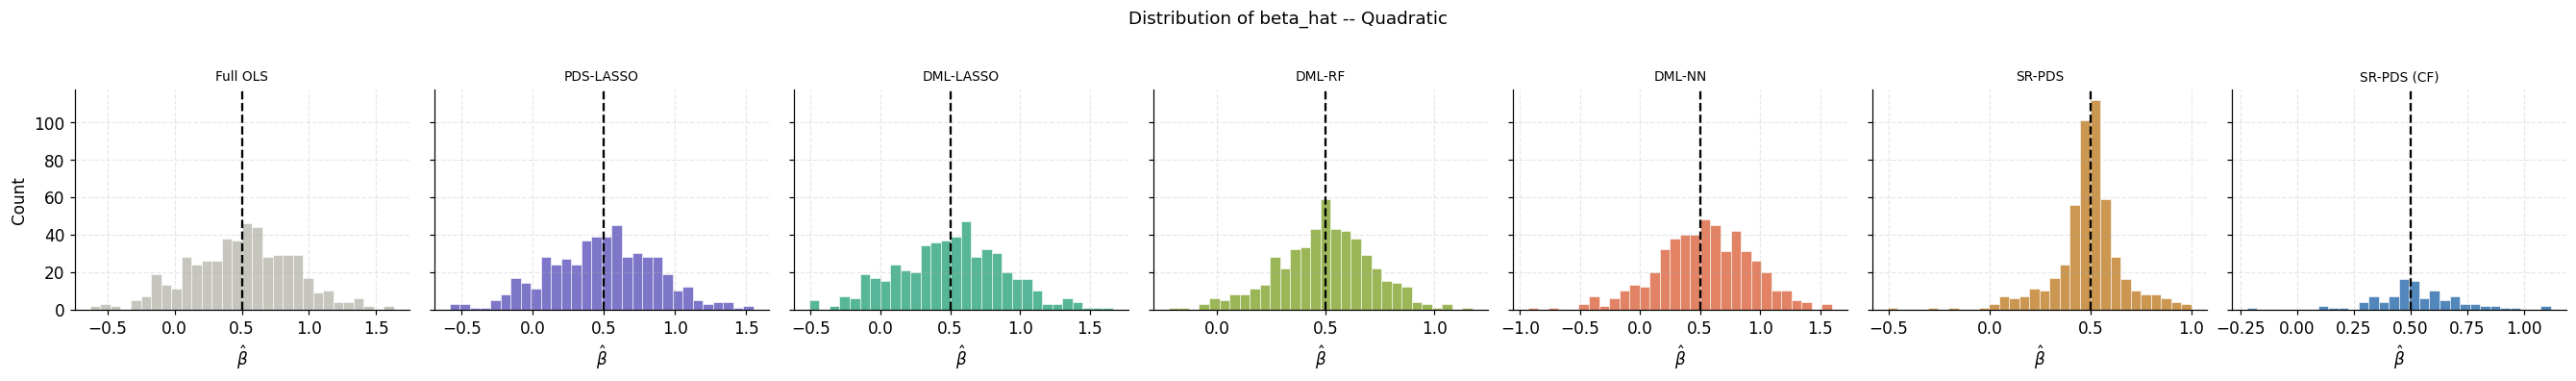

  Saved: ../figures/dist_dgp3.png


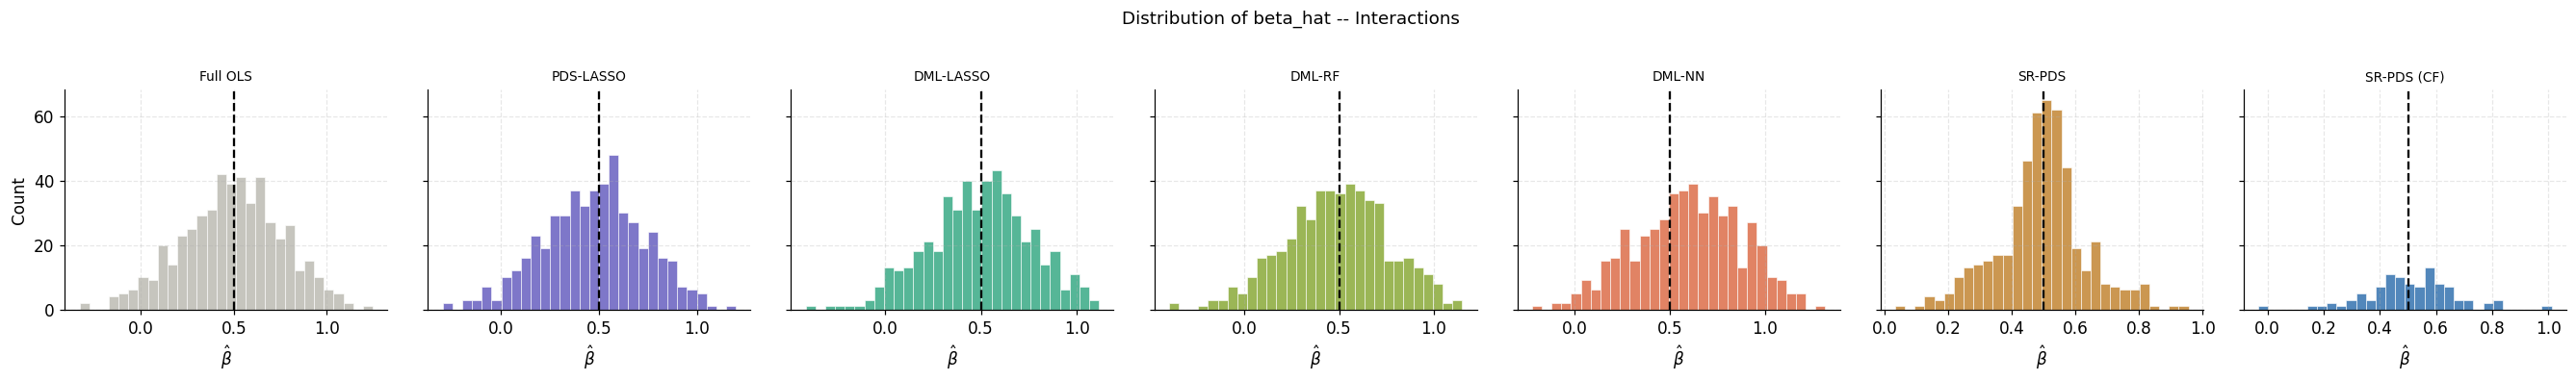

  Saved: ../figures/dist_dgp4.png


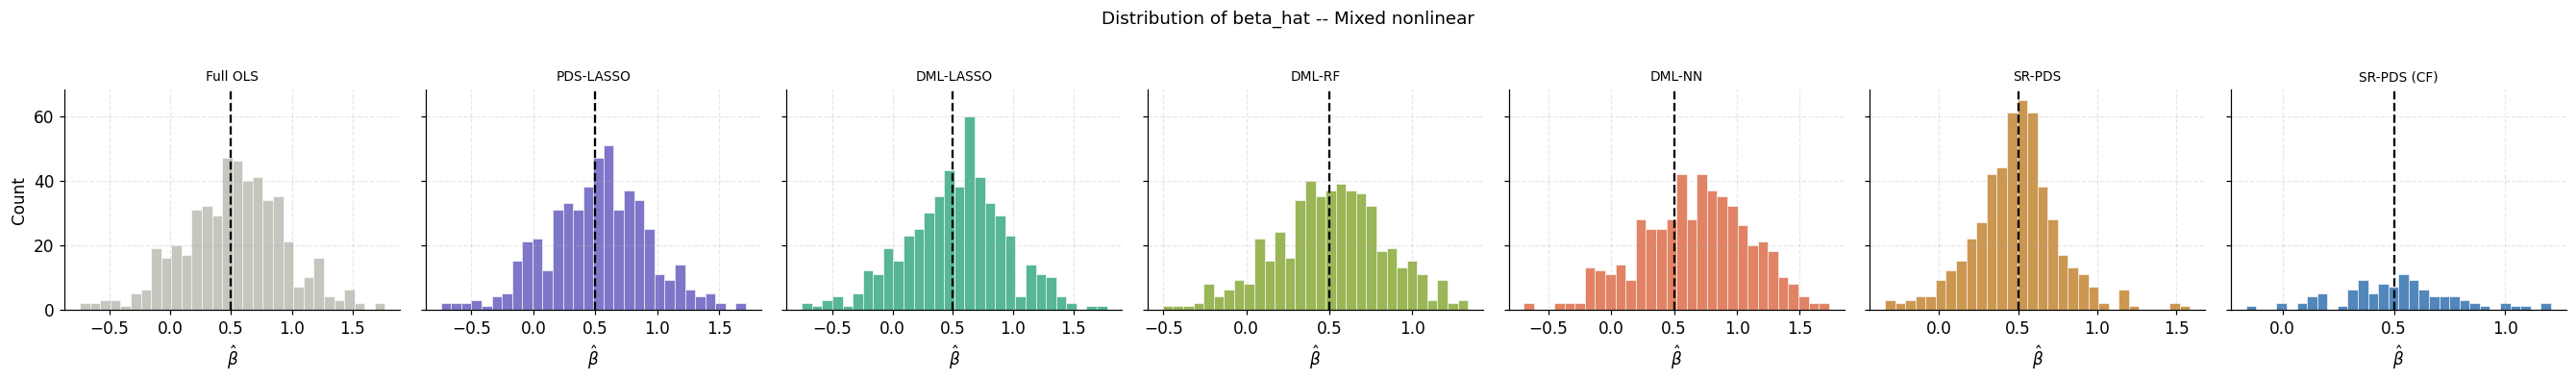

  Saved: ../figures/dist_dgp5.png


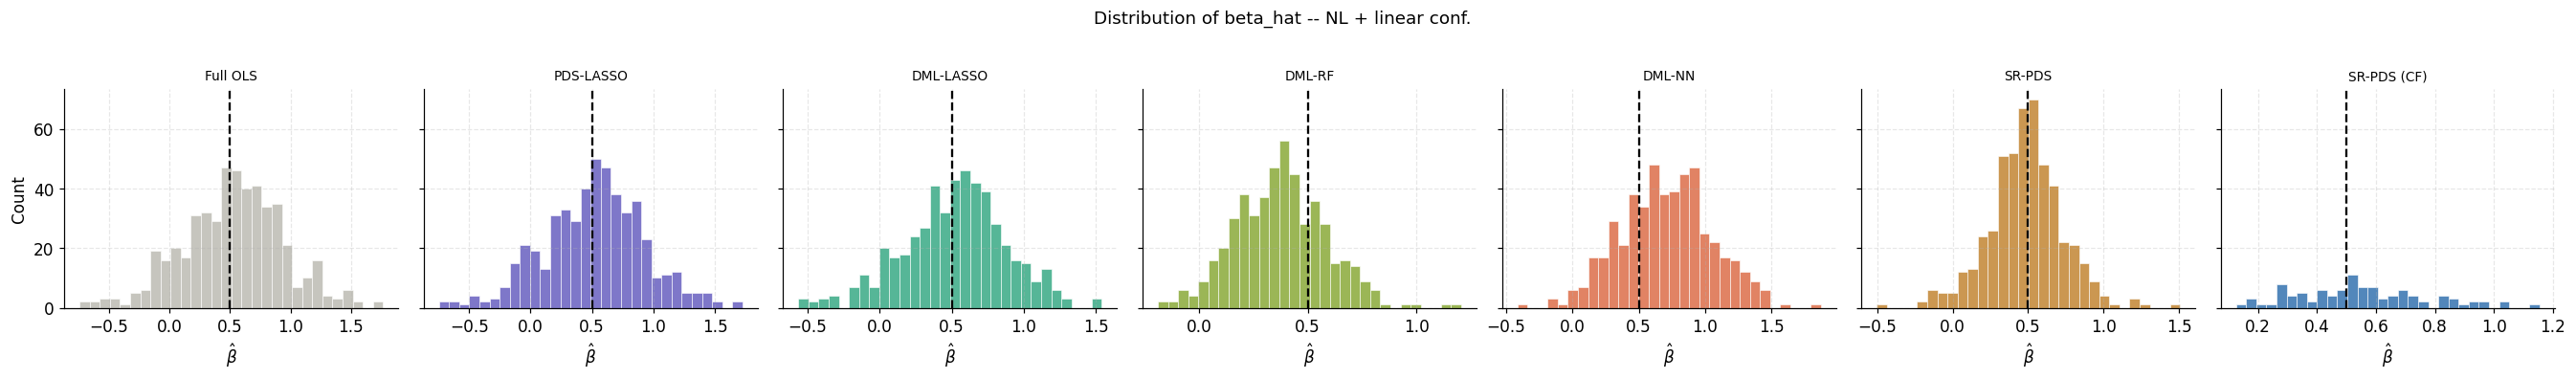

  Saved: ../figures/dist_dgp6.png


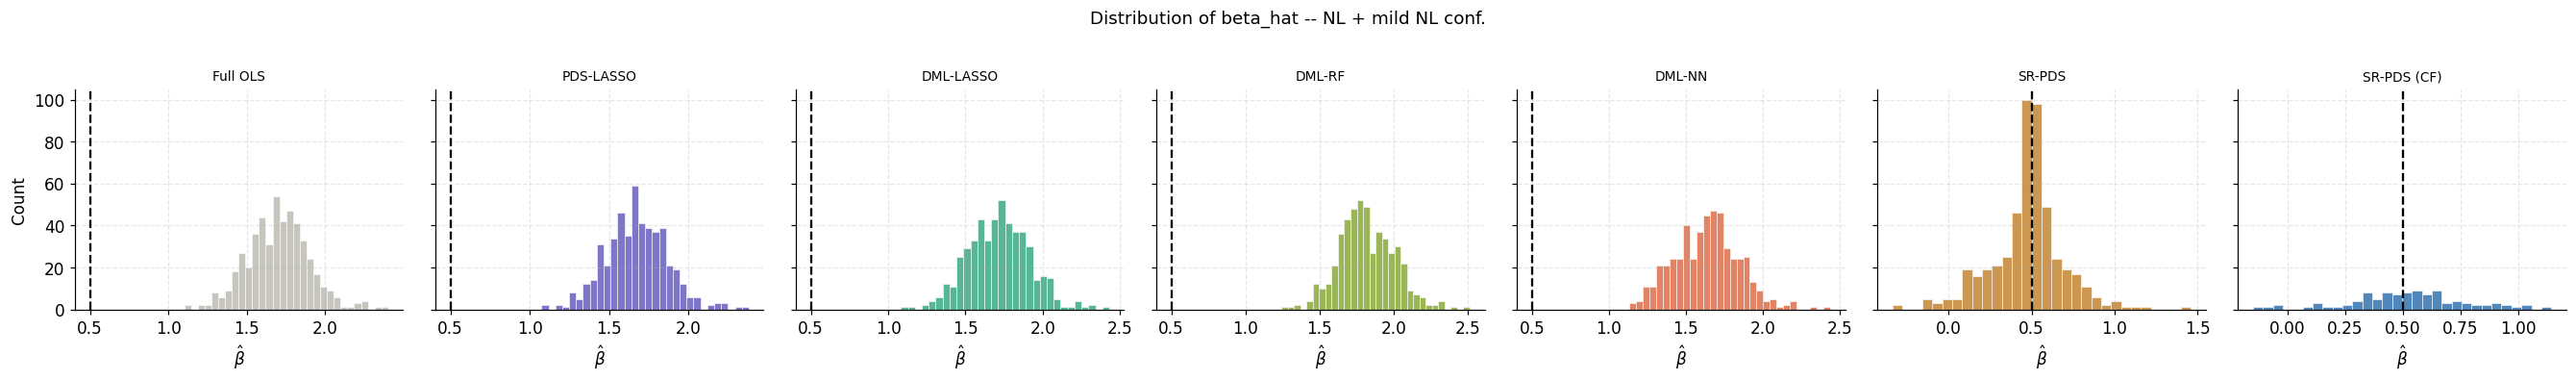

  Saved: ../figures/dist_dgp7.png


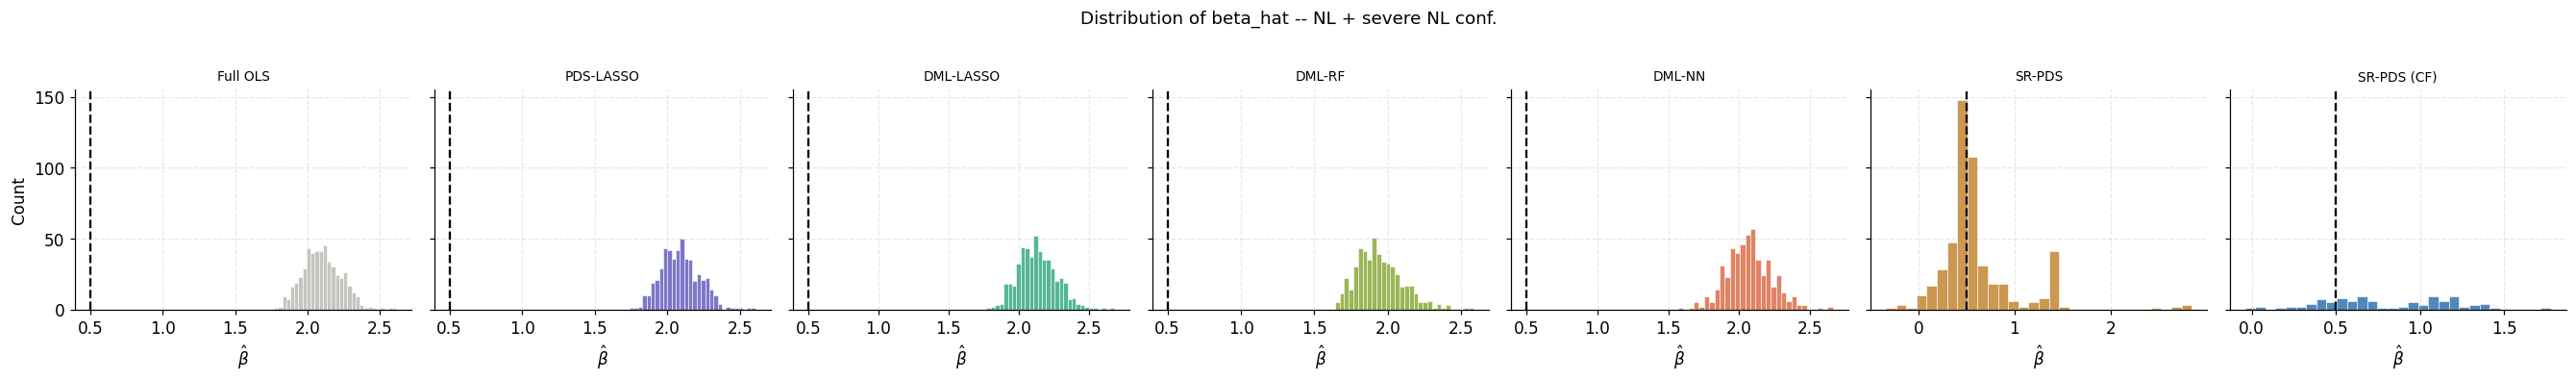

  Saved: ../figures/dist_dgp8.png


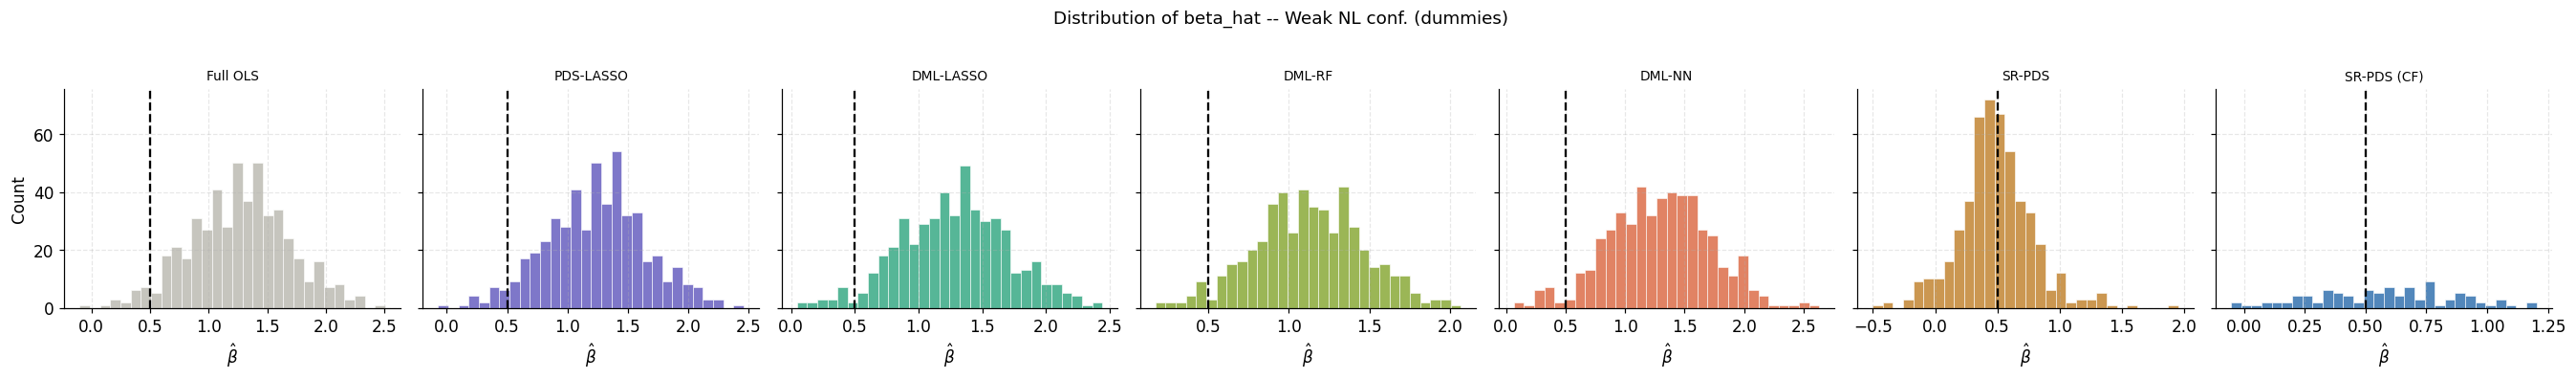

In [4]:
plot_bias(all_metrics, save=True);          plt.show()
plot_coverage(all_metrics, save=True);      plt.show()
plot_rmse_heatmap(all_metrics, save=True);  plt.show()
plot_summary_panel(all_metrics, save=True); plt.show()
for dgp_key in DGP_KEYS:
    plot_distributions(combined, BETA0, dgp_key, save=True)
    plt.show()

## 4. Recovery analysis

What did SR-PDS actually discover? For each true nonlinear term in
each DGP we measure (a) how often PySR found it pre-LASSO and (b) how
often it survived the post-LASSO selection step.

In [5]:
with open(f'{RESULTS_DIR}/sr_pds_log_headline.pkl', 'rb') as f:
    headline_log = pickle.load(f)

recovery_df = evaluate_recovery(headline_log, DGP_REGISTRY)
recovery_df.to_csv(f'{RESULTS_DIR}/recovery.csv', index=False)
print(f"Recovery records: {len(recovery_df)}")
recovery_df.head(20)

Recovery records: 96


,dgp,dgp_label,variant,equation,term,term_label,stage,recovery_rate,n_reps,true_coef,mean_coef,std_coef,coef_bias,coef_rmse
0,dgp2,Quadratic,sr_pds,y,"(sq, 0, None)",x0^2,pre_lasso,0.926,500,5.0,NaN,NaN,NaN,NaN
1,dgp2,Quadratic,sr_pds,y,"(sq, 0, None)",x0^2,post_lasso,0.926,500,5.0,4.997003,0.104935,-0.002997,0.104978
2,dgp2,Quadratic,sr_pds,y,"(sq, 2, None)",x2^2,pre_lasso,0.472,500,3.0,NaN,NaN,NaN,NaN
3,dgp2,Quadratic,sr_pds,y,"(sq, 2, None)",x2^2,post_lasso,0.472,500,3.0,3.001577,0.057449,0.001577,0.057470
4,dgp2,Quadratic,sr_pds_cf,y,"(sq, 0, None)",x0^2,pre_lasso,1.000,100,5.0,NaN,NaN,NaN,NaN
5,dgp2,Quadratic,sr_pds_cf,y,"(sq, 0, None)",x0^2,post_lasso,1.000,100,5.0,NaN,NaN,NaN,NaN
6,dgp2,Quadratic,sr_pds_cf,y,"(sq, 2, None)",x2^2,pre_lasso,0.940,100,3.0,NaN,NaN,NaN,NaN
7,dgp2,Quadratic,sr_pds_cf,y,"(sq, 2, None)",x2^2,post_lasso,0.940,100,3.0,NaN,NaN,NaN,NaN
8,dgp3,Interactions,sr_pds,y,"(int, 0, 1)",x0*x1,pre_lasso,0.866,500,5.0,NaN,NaN,NaN,NaN
9,dgp3,Interactions,sr_pds,y,"(int, 0, 1)",x0*x1,post_lasso,0.866,500,5.0,4.995158,0.122341,-0.004842,0.122436


  Saved: ../figures/recovery_heatmap_y.png


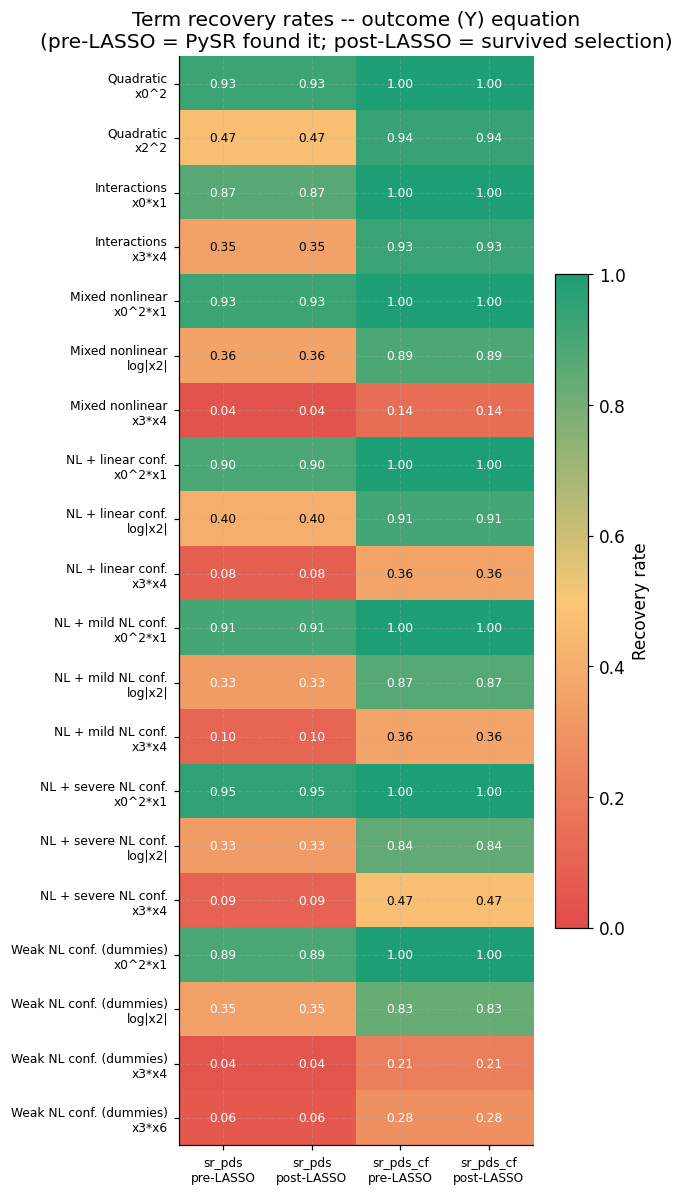

  Saved: ../figures/recovery_heatmap_d.png


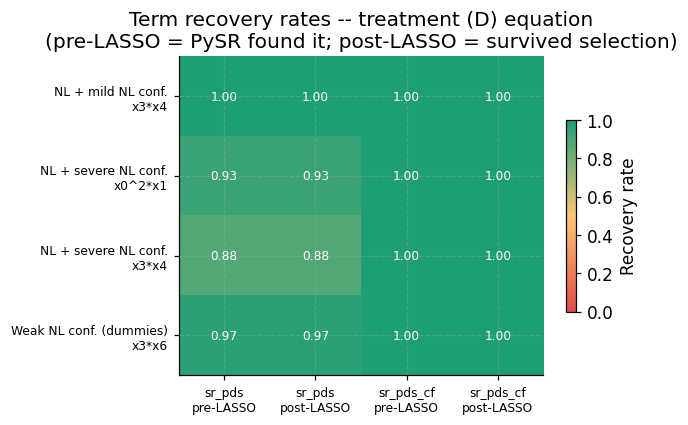

  Saved: ../figures/coef_recovery_y.png


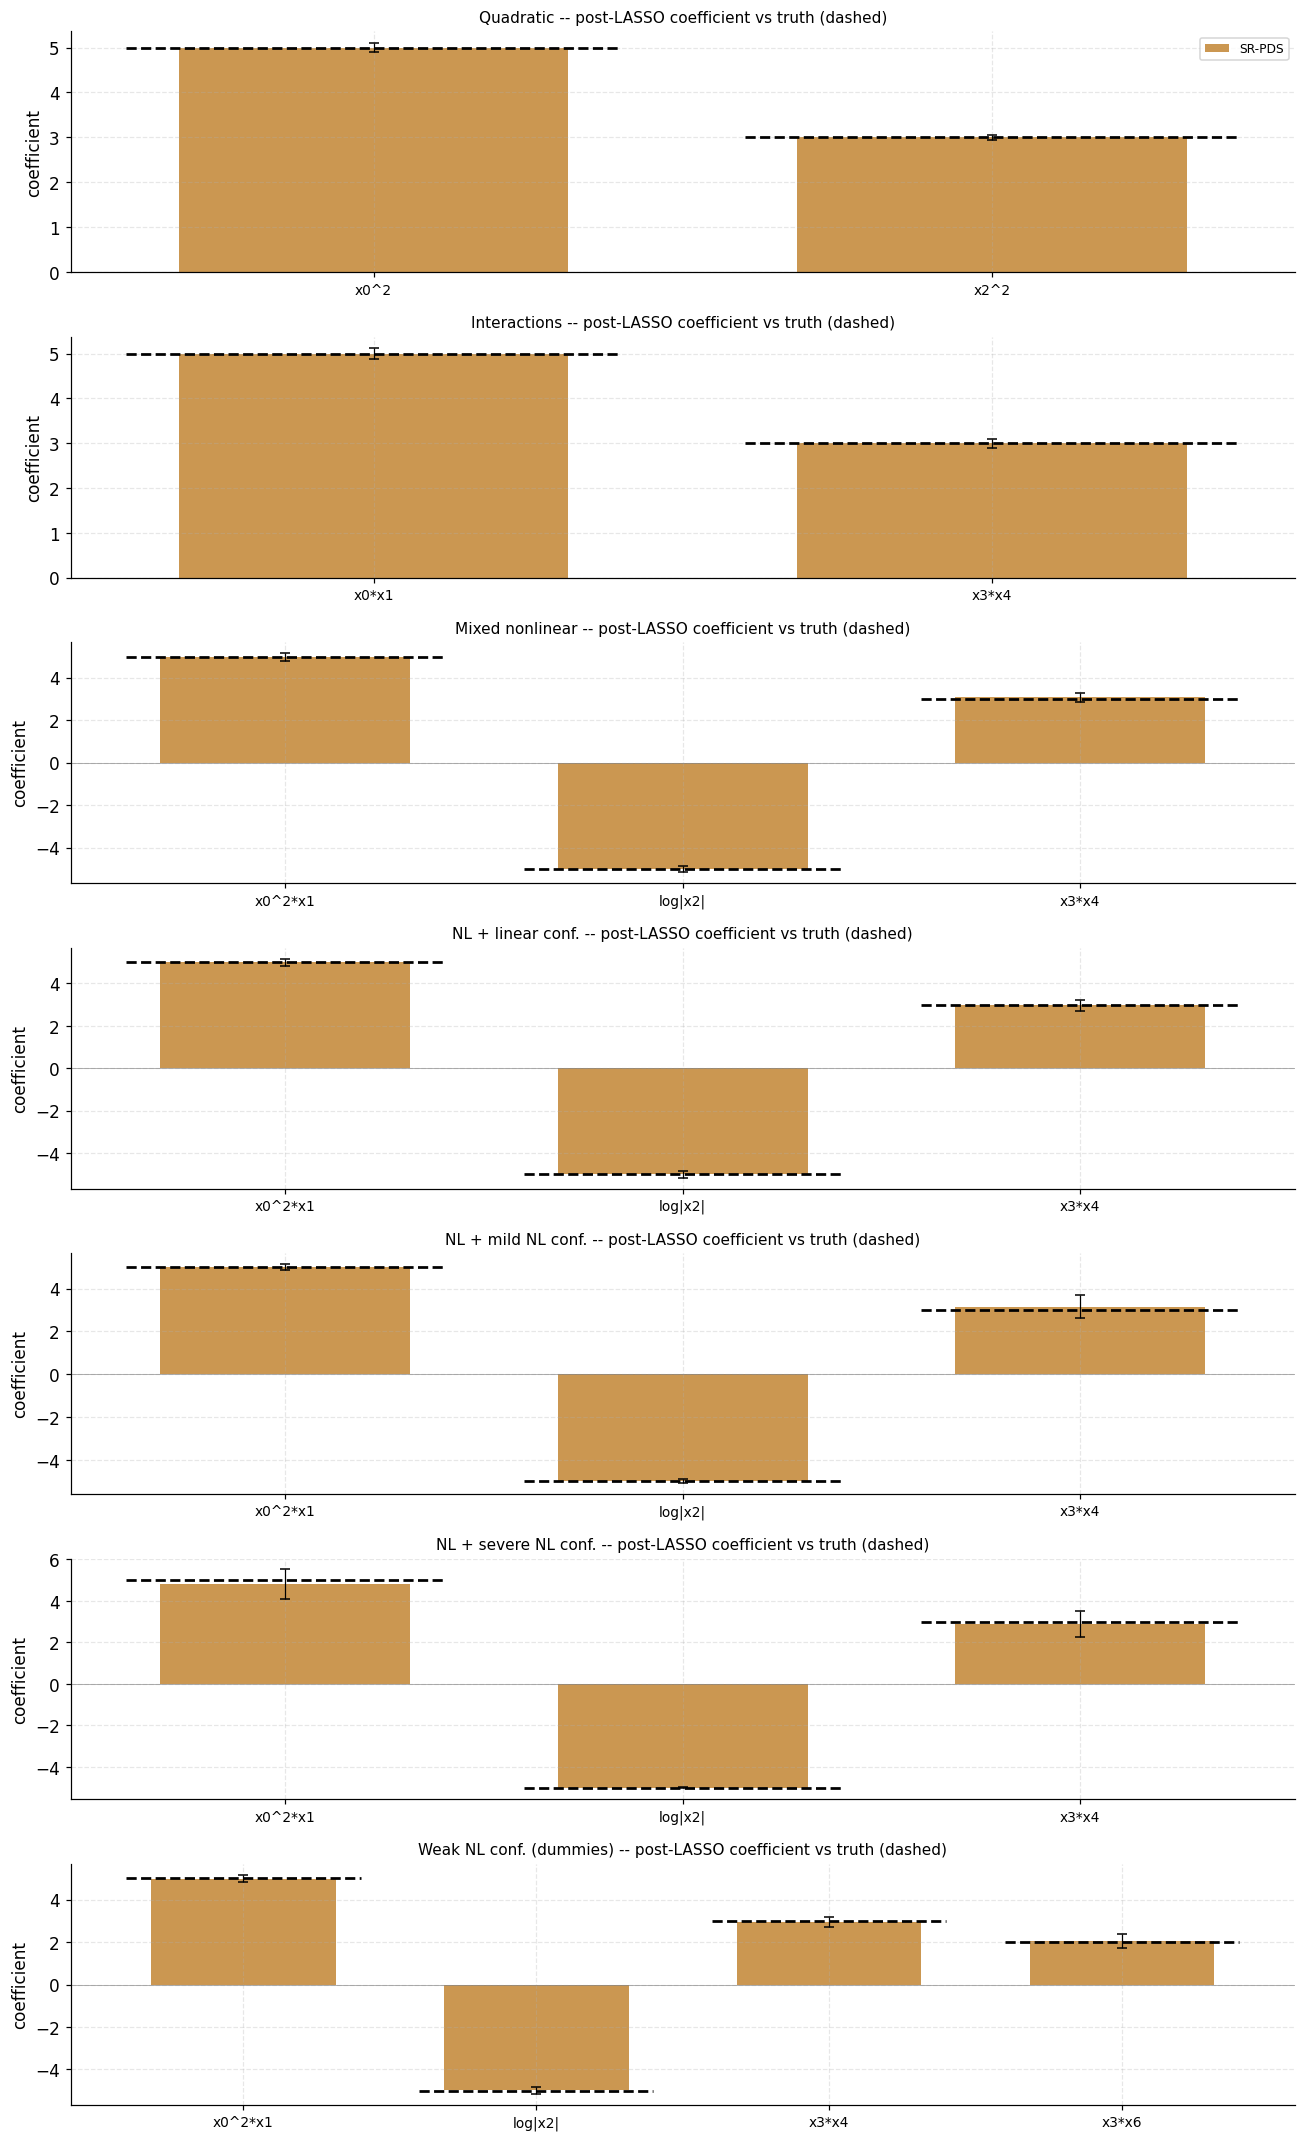

In [6]:
if not recovery_df.empty:
    plot_recovery_heatmap(recovery_df, equation='y', save=True); plt.show()
    sub_d = recovery_df[recovery_df['equation'] == 'd']
    if not sub_d.empty:
        plot_recovery_heatmap(recovery_df, equation='d', save=True); plt.show()
    plot_coefficient_recovery(recovery_df, equation='y', save=True); plt.show()

## 5. N-trajectory

How do bias and RMSE evolve as n grows? Trajectory at n in {30, 40,
..., 100, 200, 500, 1000, 2000, 5000}. SR-PDS-CF is excluded (lives at
n=500 only).

Trajectory is checkpointed every 50 (DGP, estimator, n) cells to a
partial pickle so that compute crashes mid-run don't lose everything.

In [7]:
N_GRID_TRAJ   = [30, 40, 50, 60, 70, 80, 90, 100, 200, 500, 1000, 2000, 5000]
TRAJ_EST_KEYS = [k for k in EST_KEYS if k != 'sr_pds_cf']

SR_PDS_LOG.clear()
traj_rows = []
total = len(N_GRID_TRAJ) * len(DGP_KEYS) * len(TRAJ_EST_KEYS)
i = 0
t_traj_start = time.time()

for n_grid in N_GRID_TRAJ:
    for dgp_key in DGP_KEYS:
        for est_key in TRAJ_EST_KEYS:
            i += 1
            est = ESTIMATOR_REGISTRY[est_key]
            elapsed = (time.time() - t_traj_start) / 60
            print(f"[{i:>4}/{total}] {elapsed:5.1f}min  "
                  f"n={n_grid:>5}  {dgp_key}  {est_key}", end='  ')

            df = run_simulation(
                DGP_REGISTRY[dgp_key]['fn'], est['fn'],
                estimator_key=est_key,
                n=n_grid, p=P, s=S, beta0=BETA0,
                n_reps=N_REPS_TRAJ,
                n_jobs=1 if est['requires_serial'] else N_JOBS,
                dgp_key=dgp_key,
            )
            df['dgp'] = dgp_key
            df['estimator'] = est_key
            df['dgp_label'] = DGP_REGISTRY[dgp_key]['label']
            df['est_label'] = est['label']
            df['beta0'] = BETA0
            df['n_grid'] = n_grid
            traj_rows.append(df)
            print(f"  beta={df['beta_hat'].mean():+.3f}  "
                  f"({df['failed'].sum()} failed)")

            if i % 50 == 0:
                pd.concat(traj_rows, ignore_index=True).to_pickle(
                    f'{RESULTS_DIR}/trajectory_partial.pkl')

traj_df = pd.concat(traj_rows, ignore_index=True)
traj_df.to_pickle(f'{RESULTS_DIR}/trajectory.pkl')
with open(f'{RESULTS_DIR}/sr_pds_log_traj.pkl', 'wb') as f:
    pickle.dump(list(SR_PDS_LOG), f)
print(f"\nTrajectory complete in {(time.time()-t_traj_start)/60:.1f} min")

[   1/624]   0.0min  n=   30  dgp1  full_ols  

  beta=+0.415  (0 failed)
[   2/624]   0.1min  n=   30  dgp1  pds_lasso  

  beta=+0.415  (0 failed)
[   3/624]   0.1min  n=   30  dgp1  dml_lasso  

  beta=+0.142  (0 failed)
[   4/624]   0.1min  n=   30  dgp1  dml_rf  

  beta=-0.112  (0 failed)
[   5/624]   0.3min  n=   30  dgp1  dml_nn  

...

  beta=+1.278  (0 failed)
[ 621/624] 721.0min  n= 5000  dgp8  dml_lasso  

  beta=+1.279  (0 failed)
[ 622/624] 721.0min  n= 5000  dgp8  dml_rf  

  beta=+0.759  (0 failed)
[ 623/624] 753.1min  n= 5000  dgp8  dml_nn  

  beta=+0.780  (0 failed)
[ 624/624] 753.5min  n= 5000  dgp8  sr_pds  

  beta=+0.474  (0 failed)

Trajectory complete in 776.9 min


## 6. Large-n extension

PySR runtime scales roughly linearly with n. We extend to n=10,000 on
DGPs 1, 6, 7, 8 and to n=50,000 only on DGPs 6, 7, 8 - the cases
where the structural-failure story matters most. DGP-1 at n=10,000
acts as an "easy case still works" check.

Expected runtime: ~1-2 hours on 76 cores.

In [8]:
LARGE_N_GRID = {
    10000: ['dgp1', 'dgp6', 'dgp7', 'dgp8'],
    50000: ['dgp6', 'dgp7', 'dgp8'],
}
LARGE_EST_KEYS = [k for k in EST_KEYS if k != 'sr_pds_cf']

SR_PDS_LOG.clear()
large_rows = []
total = sum(len(dgps) for dgps in LARGE_N_GRID.values()) * len(LARGE_EST_KEYS)
i = 0
t_large_start = time.time()

for n_grid, dgp_list in LARGE_N_GRID.items():
    for dgp_key in dgp_list:
        for est_key in LARGE_EST_KEYS:
            i += 1
            est = ESTIMATOR_REGISTRY[est_key]
            elapsed = (time.time() - t_large_start) / 60
            print(f"[{i:>3}/{total}] {elapsed:5.1f}min  "
                  f"n={n_grid:>6}  {dgp_key}  {est_key}")

            df = run_simulation(
                DGP_REGISTRY[dgp_key]['fn'], est['fn'],
                estimator_key=est_key,
                n=n_grid, p=P, s=S, beta0=BETA0,
                n_reps=N_REPS_TRAJ,
                n_jobs=1 if est['requires_serial'] else N_JOBS,
                dgp_key=dgp_key,
            )
            df['dgp'] = dgp_key
            df['estimator'] = est_key
            df['dgp_label'] = DGP_REGISTRY[dgp_key]['label']
            df['est_label'] = est['label']
            df['beta0'] = BETA0
            df['n_grid'] = n_grid
            large_rows.append(df)

large_df = pd.concat(large_rows, ignore_index=True)
large_df.to_pickle(f'{RESULTS_DIR}/large_n.pkl')
with open(f'{RESULTS_DIR}/sr_pds_log_large.pkl', 'wb') as f:
    pickle.dump(list(SR_PDS_LOG), f)
print(f"\nLarge-n complete in {(time.time()-t_large_start)/60:.1f} min")

[  1/42]   0.0min  n= 10000  dgp1  full_ols


[  2/42]   0.2min  n= 10000  dgp1  pds_lasso


[  3/42]   0.2min  n= 10000  dgp1  dml_lasso


[  4/42]   0.2min  n= 10000  dgp1  dml_rf


[  5/42]  69.2min  n= 10000  dgp1  dml_nn


...

[ 25/42] 482.6min  n= 50000  dgp6  full_ols


[ 26/42] 482.8min  n= 50000  dgp6  pds_lasso


[ 27/42] 482.9min  n= 50000  dgp6  dml_lasso


[ 28/42] 482.9min  n= 50000  dgp6  dml_rf


KeyboardInterrupt: 

Interim - stopped running for n = 50,000, saving what we have below

In [9]:
# Discover what variables hold results
import sys
result_vars = [k for k in dir() if 'result' in k.lower() or 'metric' in k.lower() or 'large' in k.lower()]
for v in result_vars:
    obj = eval(v)
    print(f"{v:30s}  type={type(obj).__name__:15s}  size={sys.getsizeof(obj)}")

LARGE_EST_KEYS                  type=list             size=120
LARGE_N_GRID                    type=dict             size=224
RESULTS_DIR                     type=str              size=64
all_metrics                     type=DataFrame        size=17548
large_rows                      type=list             size=312
t_large_start                   type=float            size=24


In [12]:
import pandas as pd

for name in dir():
    if name.startswith('_'):
        continue
    try:
        obj = eval(name)
        if isinstance(obj, pd.DataFrame):
            cols = obj.columns.tolist()
            print(f"{name}: shape={obj.shape}, cols={cols}")
    except Exception:
        pass

all_metrics: shape=(56, 10), cols=['dgp', 'dgp_label', 'estimator', 'est_label', 'bias', 'rmse', 'coverage', 'size', 'std', 'n_reps']
combined: shape=(24800, 19), cols=['seed', 'failed', 'beta_hat', 'se', 'ci_low', 'ci_high', 'dgp', 'estimator', 'dgp_label', 'est_label', 'beta0', 'sr_pds_variant', 'epds_variant', 'pre_lasso_terms_y', 'pre_lasso_terms_d', 'post_lasso_terms_y', 'post_lasso_terms_d', 'term_coefs_y', 'term_coefs_d']
df: shape=(25, 12), cols=['seed', 'failed', 'beta_hat', 'se', 'ci_low', 'ci_high', 'dgp', 'estimator', 'dgp_label', 'est_label', 'beta0', 'n_grid']
recovery_df: shape=(96, 14), cols=['dgp', 'dgp_label', 'variant', 'equation', 'term', 'term_label', 'stage', 'recovery_rate', 'n_reps', 'true_coef', 'mean_coef', 'std_coef', 'coef_bias', 'coef_rmse']
sub_d: shape=(16, 14), cols=['dgp', 'dgp_label', 'variant', 'equation', 'term', 'term_label', 'stage', 'recovery_rate', 'n_reps', 'true_coef', 'mean_coef', 'std_coef', 'coef_bias', 'coef_rmse']
traj_df: shape=(15600, 20

In [13]:
import os, pickle
os.makedirs('../results_full', exist_ok=True)

# Headline summary
all_metrics.to_csv('../results_full/headline_metrics.csv', index=False)
all_metrics.to_pickle('../results_full/headline_metrics.pkl')
print(f"Saved headline_metrics: {all_metrics.shape}")

# SR-PDS recovery log
from estimators import SR_PDS_LOG
with open('../results_full/sr_pds_log.pkl', 'wb') as f:
    pickle.dump(SR_PDS_LOG, f)
print(f"Saved SR_PDS_LOG: {len(SR_PDS_LOG)} entries")

# Verify files
for f in sorted(os.listdir('../results_full')):
    print(f"  {f}: {os.path.getsize('../results_full/' + f)/1024:.1f} KB")

Saved headline_metrics: (56, 10)
Saved SR_PDS_LOG: 100 entries
  all_results.csv: 4434.7 KB
  dgp1_dml_lasso.csv: 60.3 KB
  dgp1_dml_nn.csv: 57.1 KB
  dgp1_dml_rf.csv: 57.5 KB
  dgp1_full_ols.csv: 59.3 KB
  dgp1_pds_lasso.csv: 60.3 KB
  dgp1_sr_pds.csv: 87.1 KB
  dgp1_sr_pds_cf.csv: 26.0 KB
  dgp2_dml_lasso.csv: 61.8 KB
  dgp2_dml_nn.csv: 58.9 KB
  dgp2_dml_rf.csv: 59.0 KB
  dgp2_full_ols.csv: 60.9 KB
  dgp2_pds_lasso.csv: 61.8 KB
  dgp2_sr_pds.csv: 144.3 KB
  dgp2_sr_pds_cf.csv: 34.0 KB
  dgp3_dml_lasso.csv: 63.3 KB
  dgp3_dml_nn.csv: 60.2 KB
  dgp3_dml_rf.csv: 60.4 KB
  dgp3_full_ols.csv: 62.4 KB
  dgp3_pds_lasso.csv: 63.4 KB
  dgp3_sr_pds.csv: 134.5 KB
  dgp3_sr_pds_cf.csv: 33.2 KB
  dgp4_dml_lasso.csv: 64.7 KB
  dgp4_dml_nn.csv: 61.7 KB
  dgp4_dml_rf.csv: 61.9 KB
  dgp4_full_ols.csv: 63.8 KB
  dgp4_pds_lasso.csv: 64.7 KB
  dgp4_sr_pds.csv: 154.8 KB
  dgp4_sr_pds_cf.csv: 39.3 KB
  dgp5_dml_lasso.csv: 65.7 KB
  dgp5_dml_nn.csv: 62.6 KB
  dgp5_dml_rf.csv: 63.1 KB
  dgp5_full_ols.csv: 

In [14]:
focus = all_metrics[all_metrics['dgp'].isin(['dgp6', 'dgp7', 'dgp8'])][
    ['dgp_label', 'est_label', 'bias', 'rmse', 'coverage']
].sort_values(['dgp_label', 'est_label'])
print(focus.to_string(index=False))

              dgp_label   est_label    bias   rmse  coverage
     NL + mild NL conf.   DML-LASSO  1.2147 1.2309     0.000
     NL + mild NL conf.      DML-NN  1.1334 1.1527     0.002
     NL + mild NL conf.      DML-RF  1.3196 1.3326     0.000
     NL + mild NL conf.    Full OLS  1.2003 1.2160     0.000
     NL + mild NL conf.   PDS-LASSO  1.1726 1.1882     0.000
     NL + mild NL conf.      SR-PDS -0.0253 0.2161     0.950
     NL + mild NL conf. SR-PDS (CF)  0.0244 0.2518     0.910
   NL + severe NL conf.   DML-LASSO  1.6311 1.6369     0.000
   NL + severe NL conf.      DML-NN  1.5677 1.5754     0.000
   NL + severe NL conf.      DML-RF  1.4433 1.4517     0.000
   NL + severe NL conf.    Full OLS  1.5985 1.6039     0.000
   NL + severe NL conf.   PDS-LASSO  1.5890 1.5945     0.000
   NL + severe NL conf.      SR-PDS  0.1103 0.4235     0.834
   NL + severe NL conf. SR-PDS (CF)  0.2991 0.4778     0.540
Weak NL conf. (dummies)   DML-LASSO  0.7822 0.8901     0.492
Weak NL conf. (dummies) 

Plotting everything I want for diss

In [19]:
import matplotlib.pyplot as plt
from plots import (
    plot_summary_panel,
    plot_bias,
    plot_coverage,
    plot_rmse_heatmap,
    plot_n_trajectory,
    plot_recovery_heatmap,
    plot_coefficient_recovery,
    plot_distributions,
    plot_recovery_vs_n,
)

  Saved: ../figures/summary_panel.png


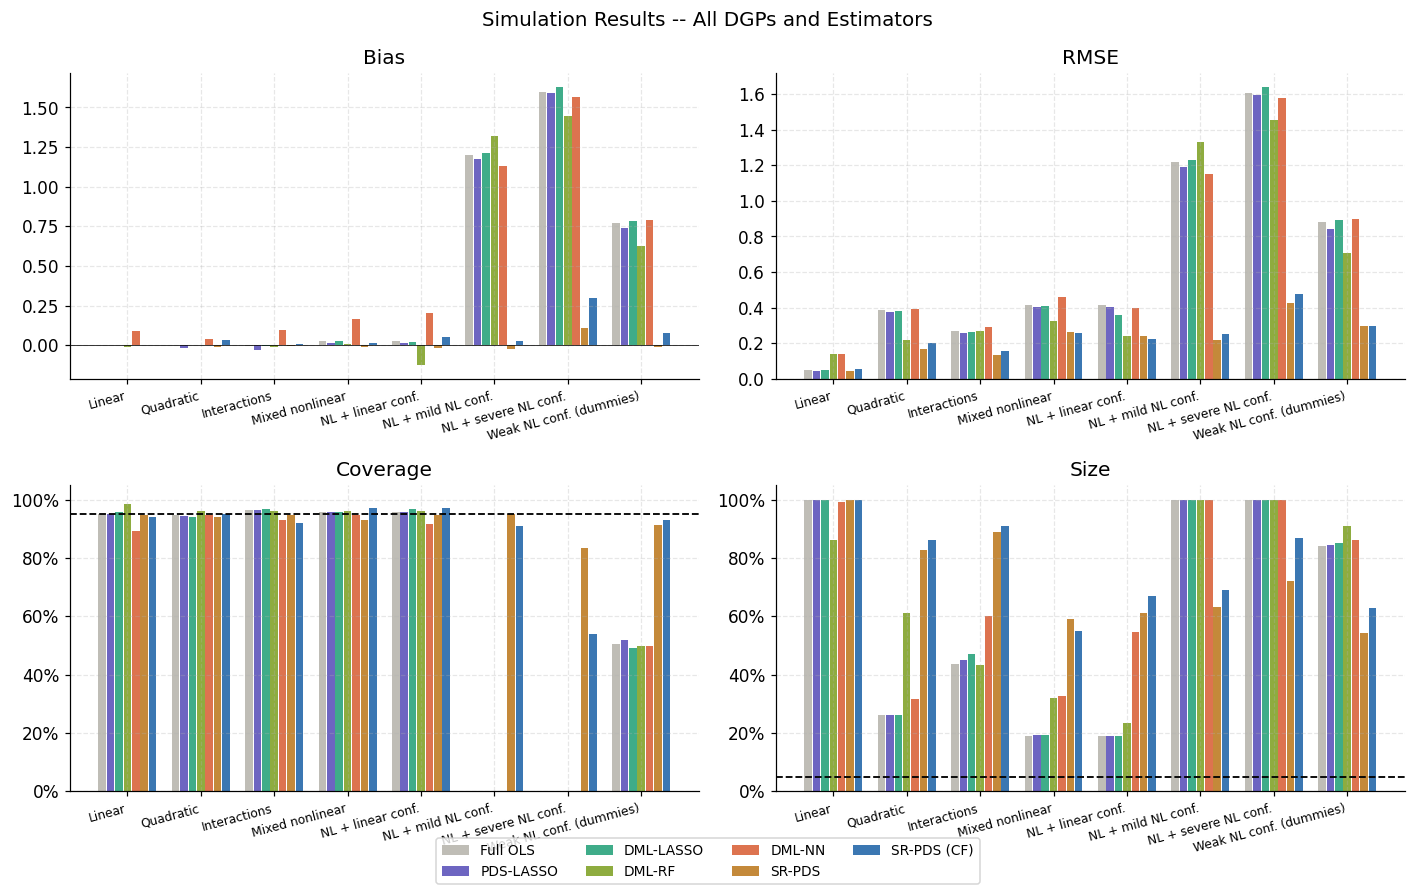

In [20]:
plot_summary_panel(all_metrics, save=True)
plt.show()

  Saved: ../figures/bias.png


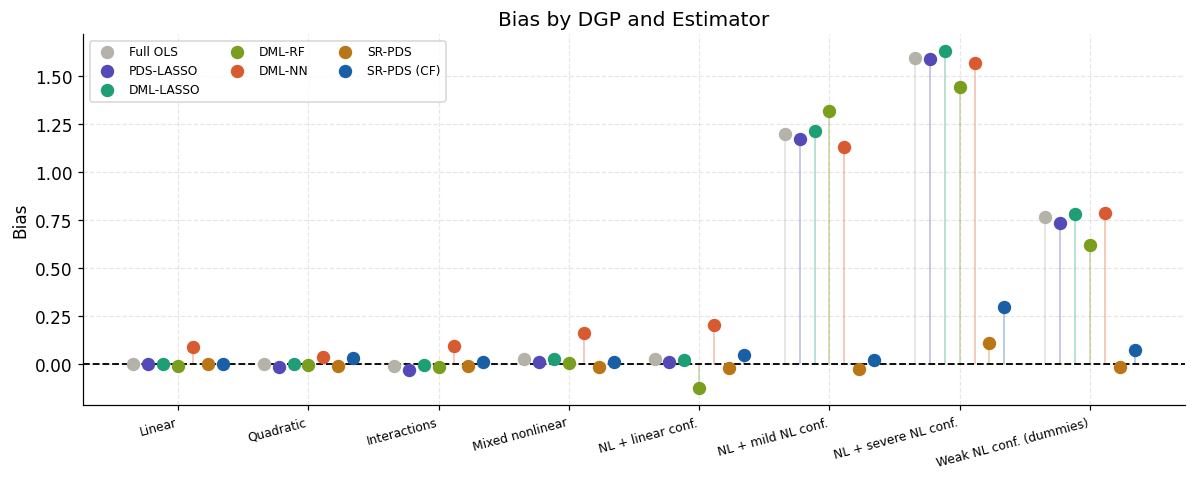

In [21]:
plot_bias(all_metrics, save=True)
plt.show()

  Saved: ../figures/coverage.png


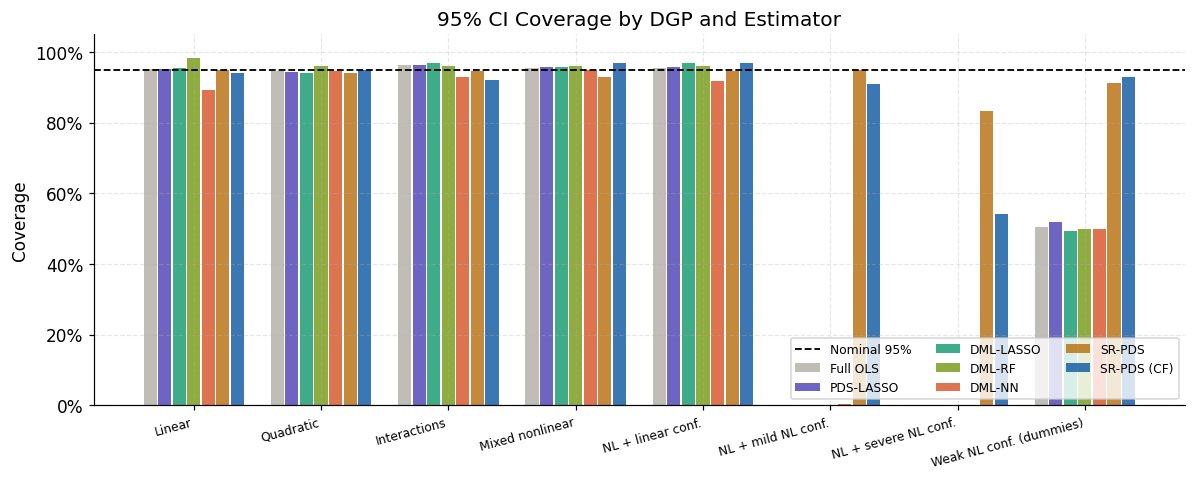

In [22]:
plot_coverage(all_metrics, save=True)
plt.show()

  Saved: ../figures/rmse_heatmap.png


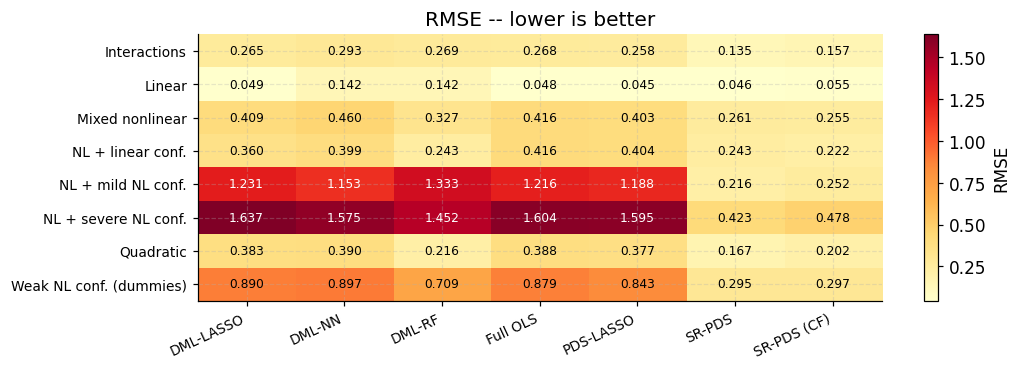

In [23]:
plot_rmse_heatmap(all_metrics, save=True)
plt.show()

  Saved: ../figures/n_trajectory.png


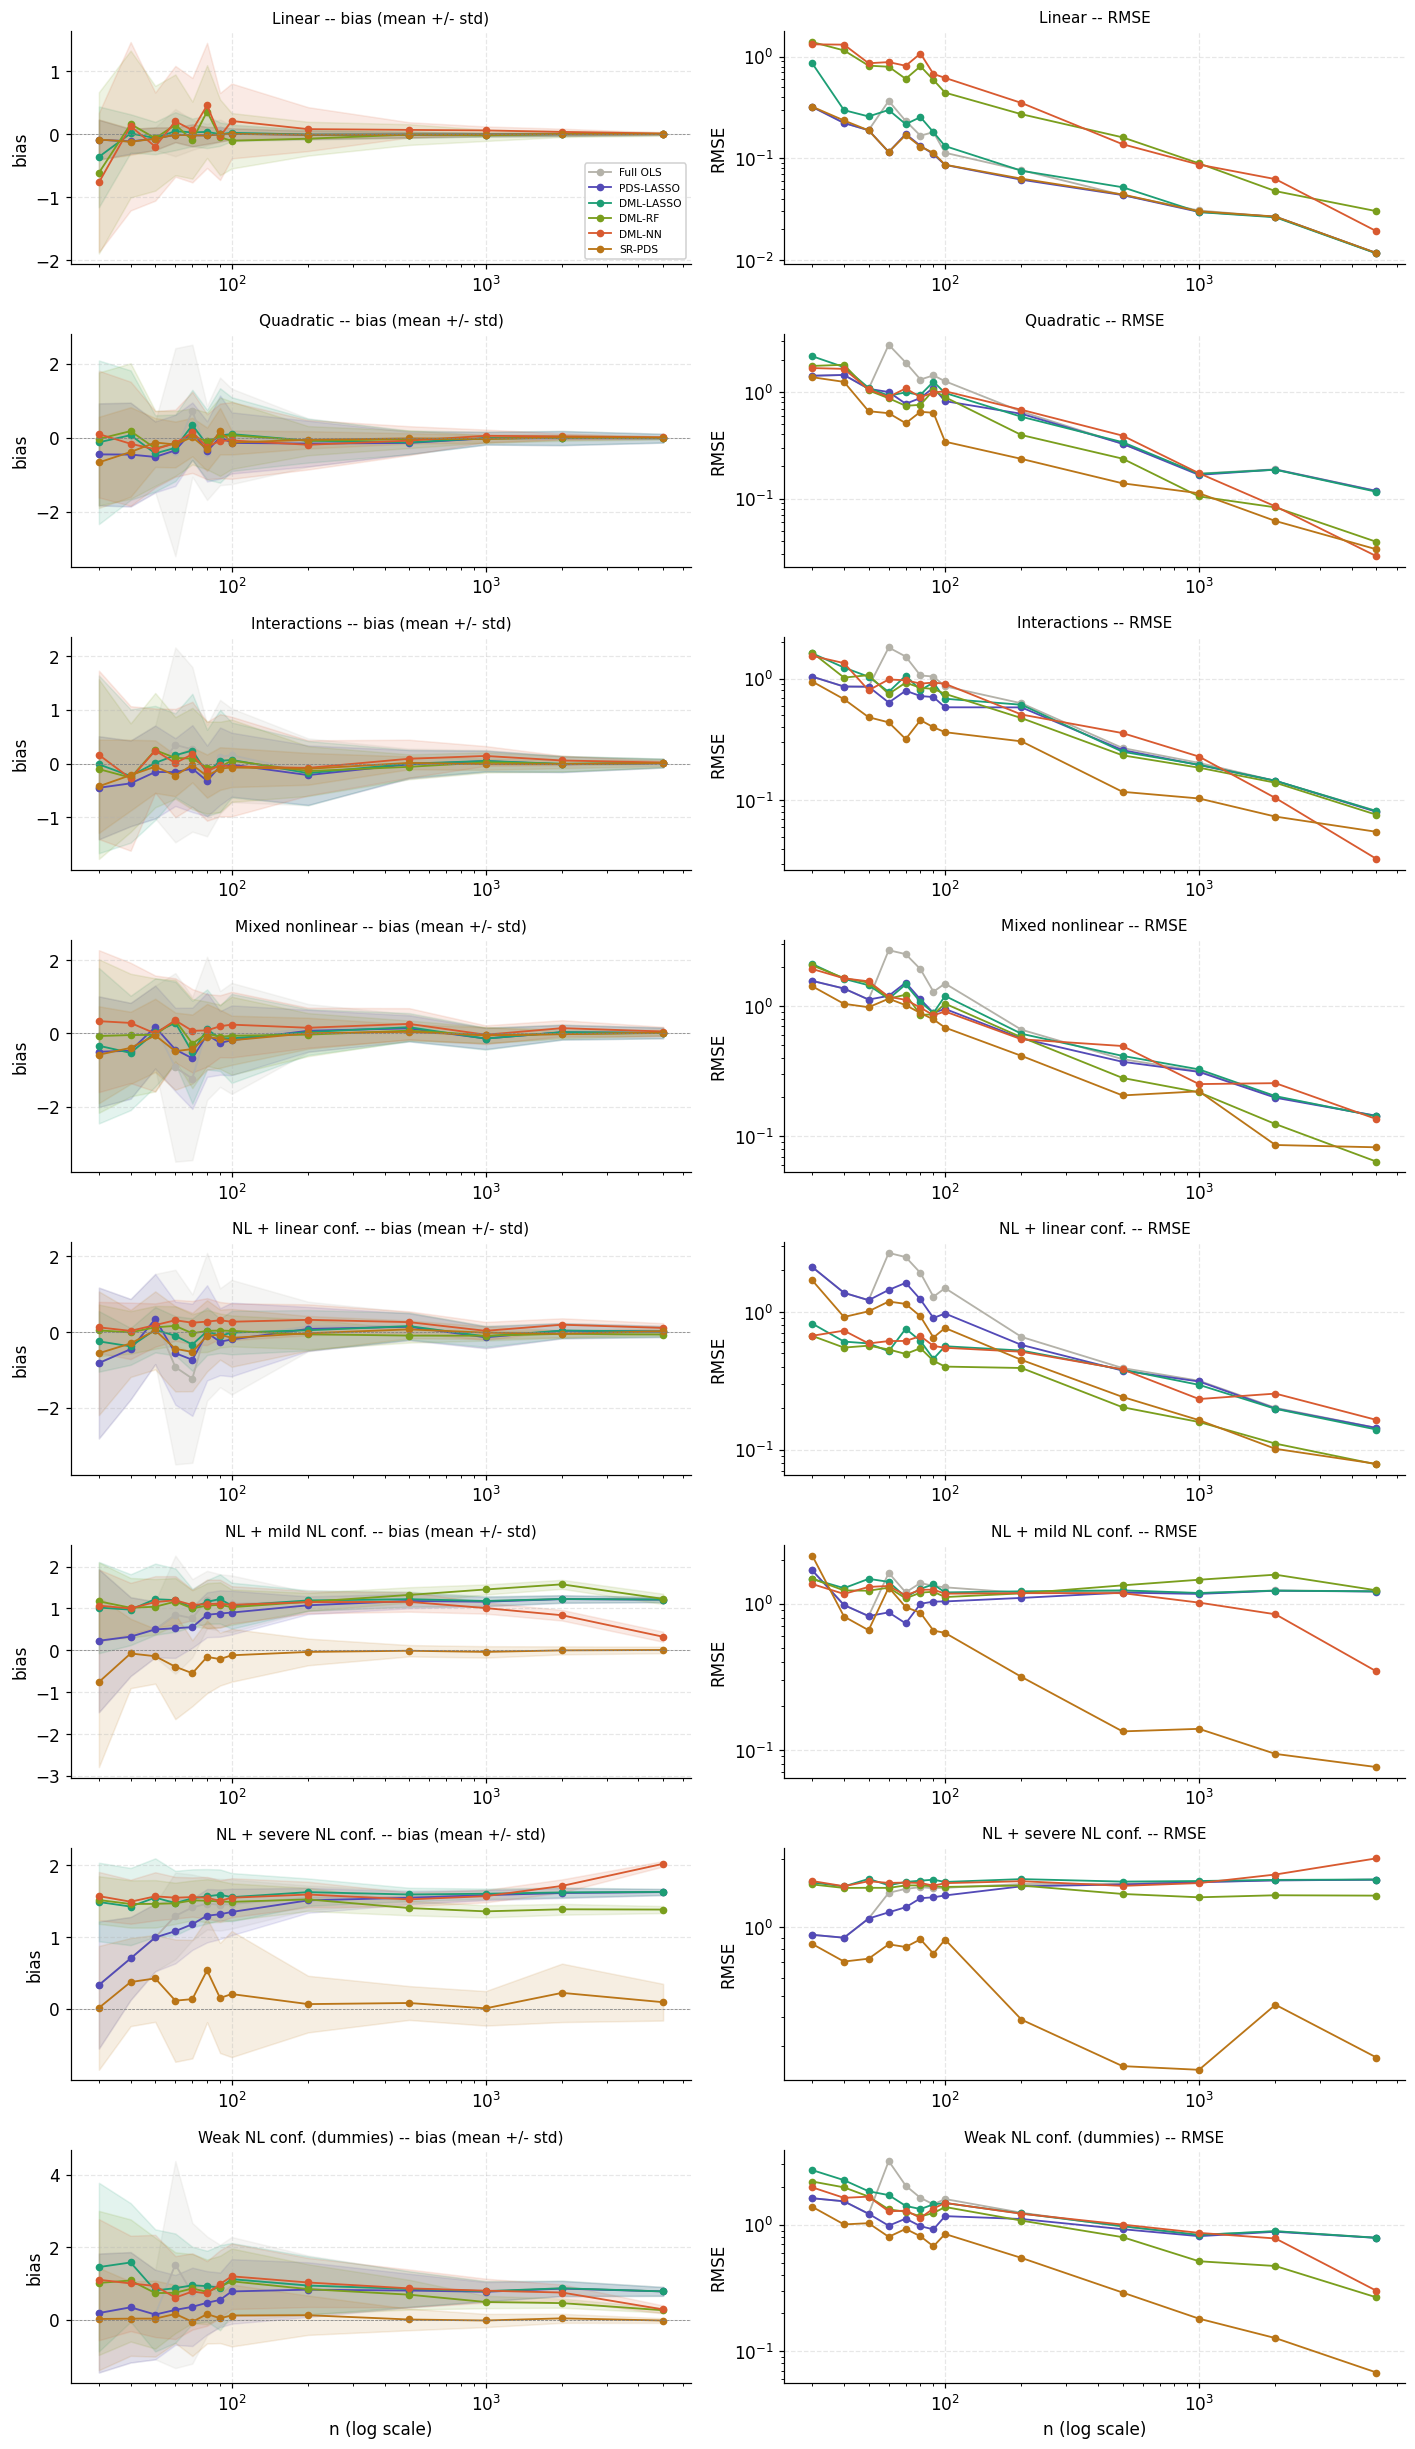

In [24]:
plot_n_trajectory(traj_df, beta0=0.5, log_y=True, save=True)
plt.show()

  Saved: ../figures/recovery_heatmap_y.png


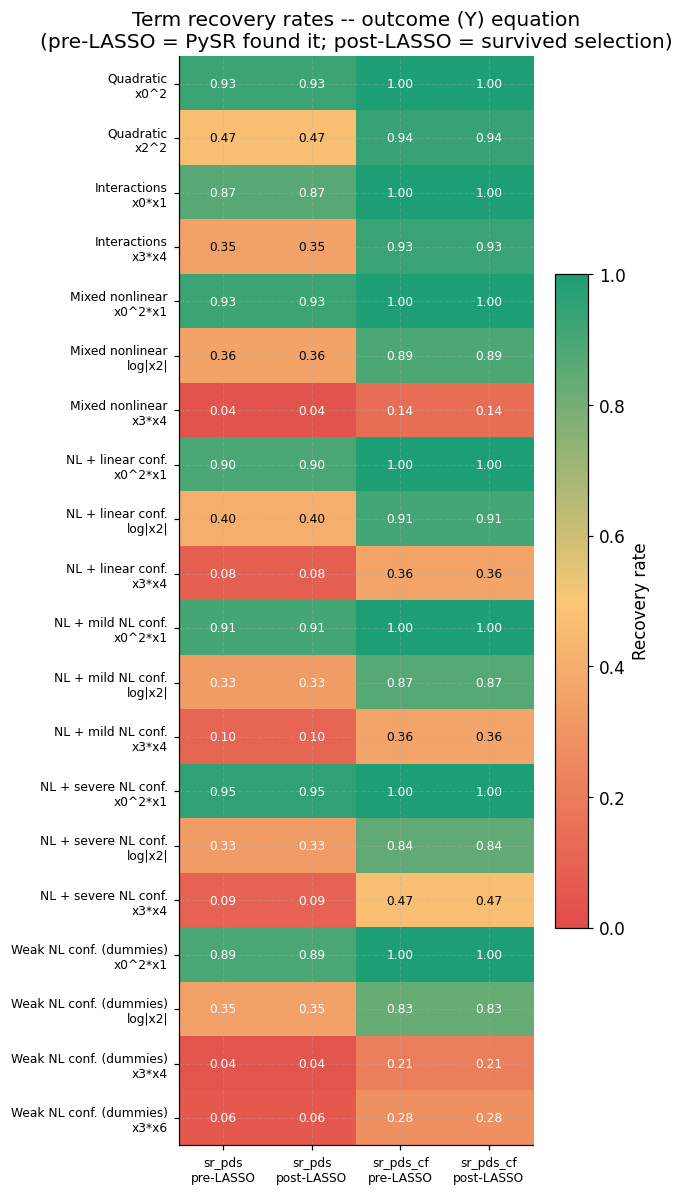

  Saved: ../figures/recovery_heatmap_d.png


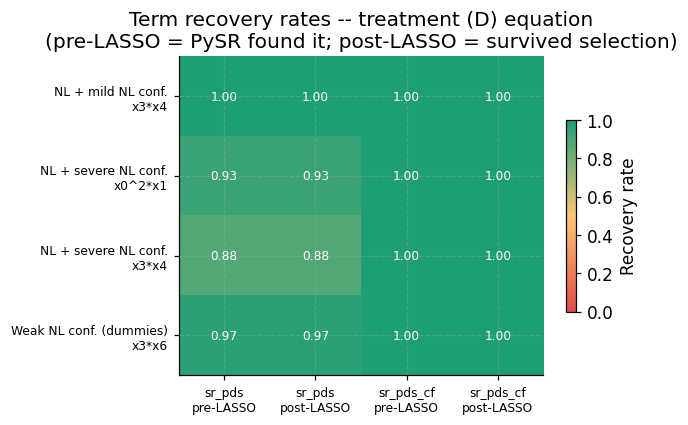

In [25]:
plot_recovery_heatmap(recovery_df, equation='y', save=True)
plt.show()

plot_recovery_heatmap(recovery_df, equation='d', save=True)
plt.show()

  Saved: ../figures/coef_recovery_y.png


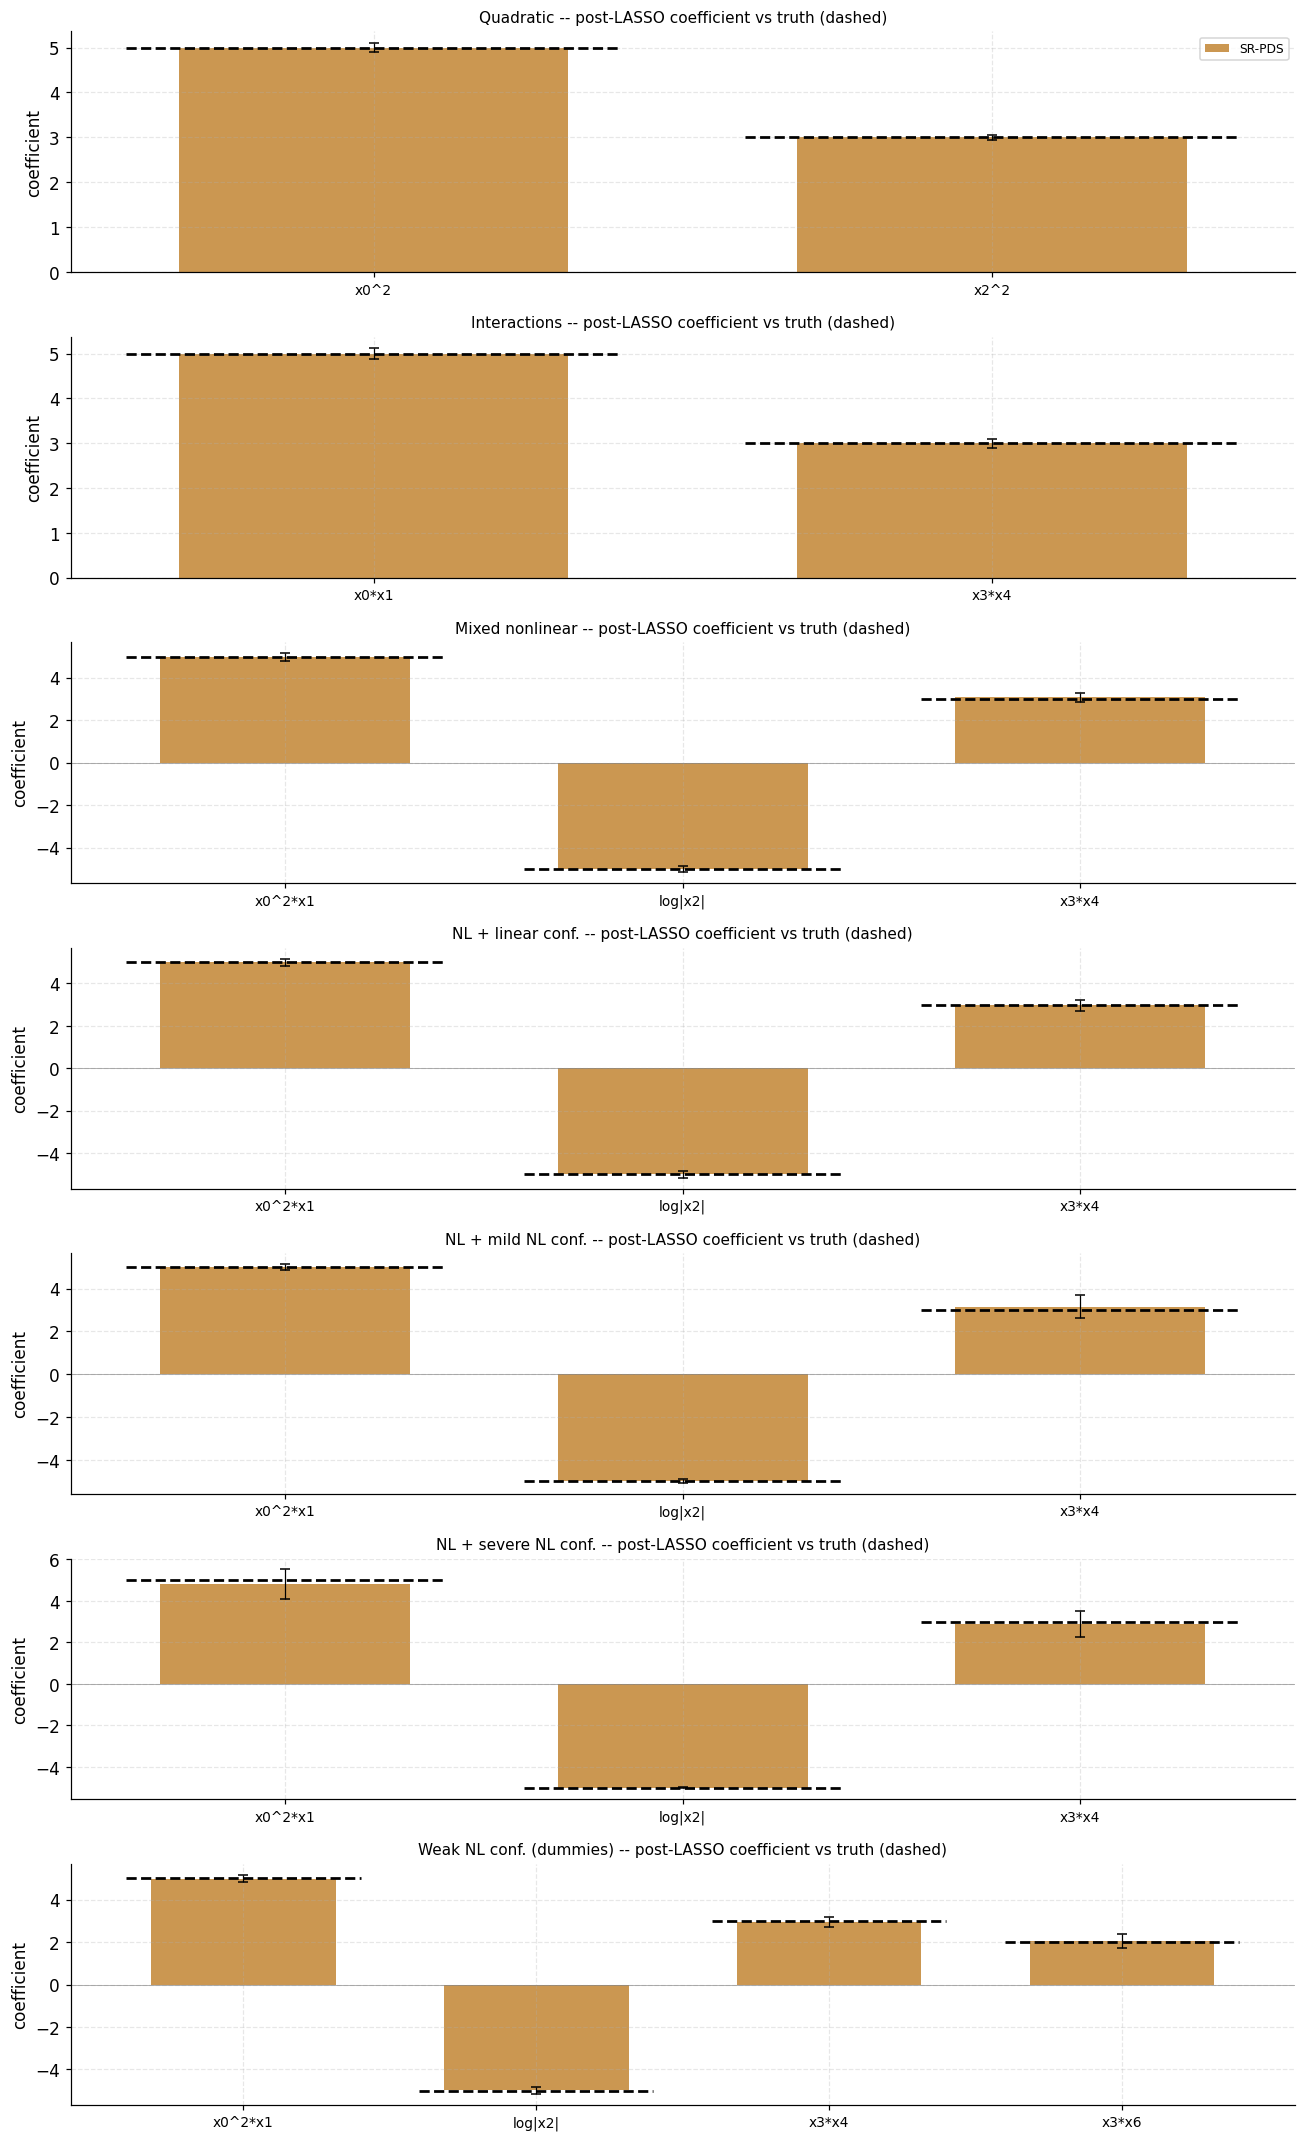

In [26]:
plot_coefficient_recovery(recovery_df, equation='y', save=True)
plt.show()

  Saved: ../figures/dist_dgp6.png


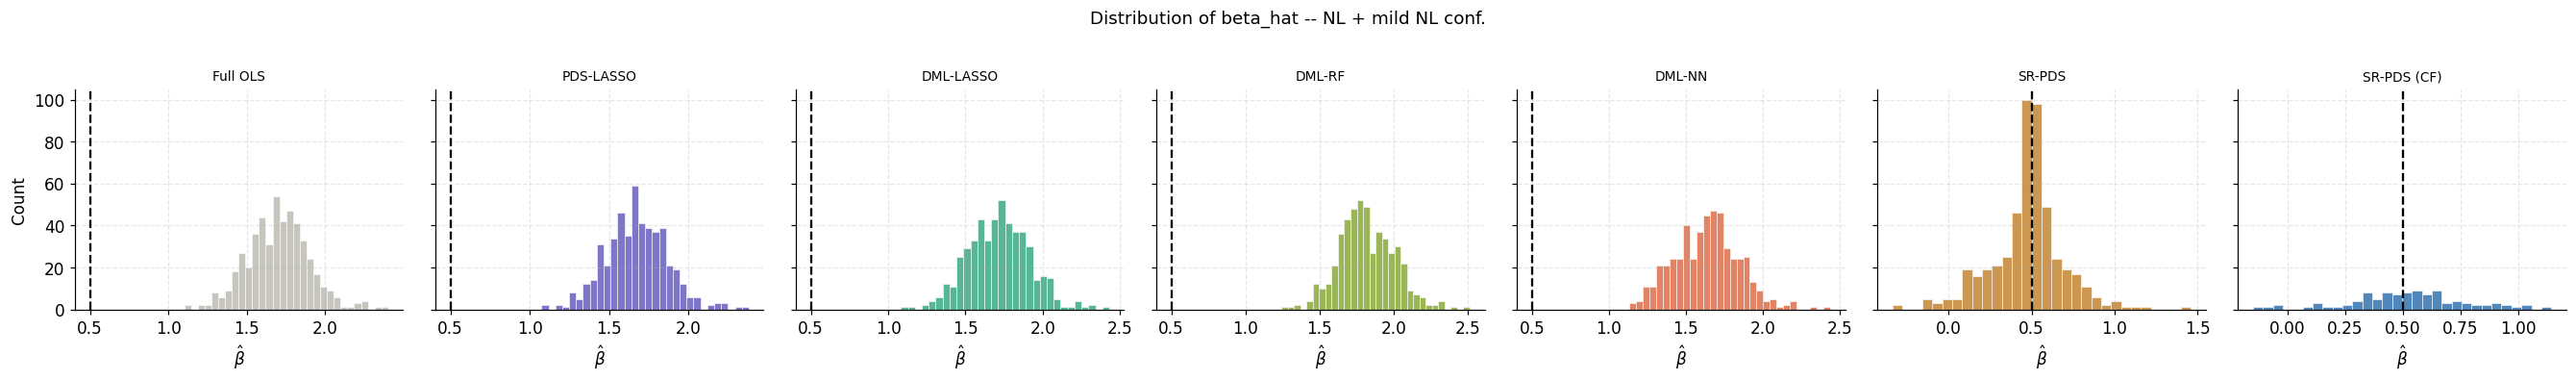

  Saved: ../figures/dist_dgp7.png


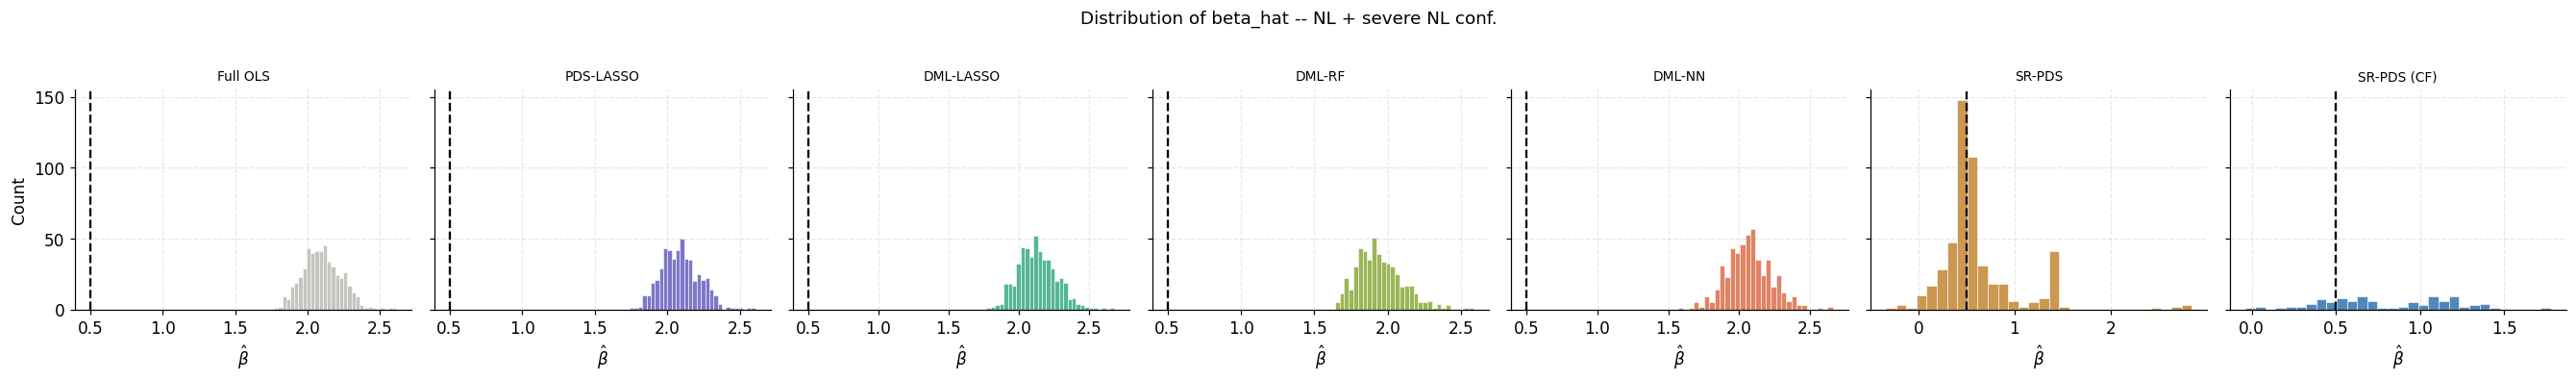

  Saved: ../figures/dist_dgp8.png


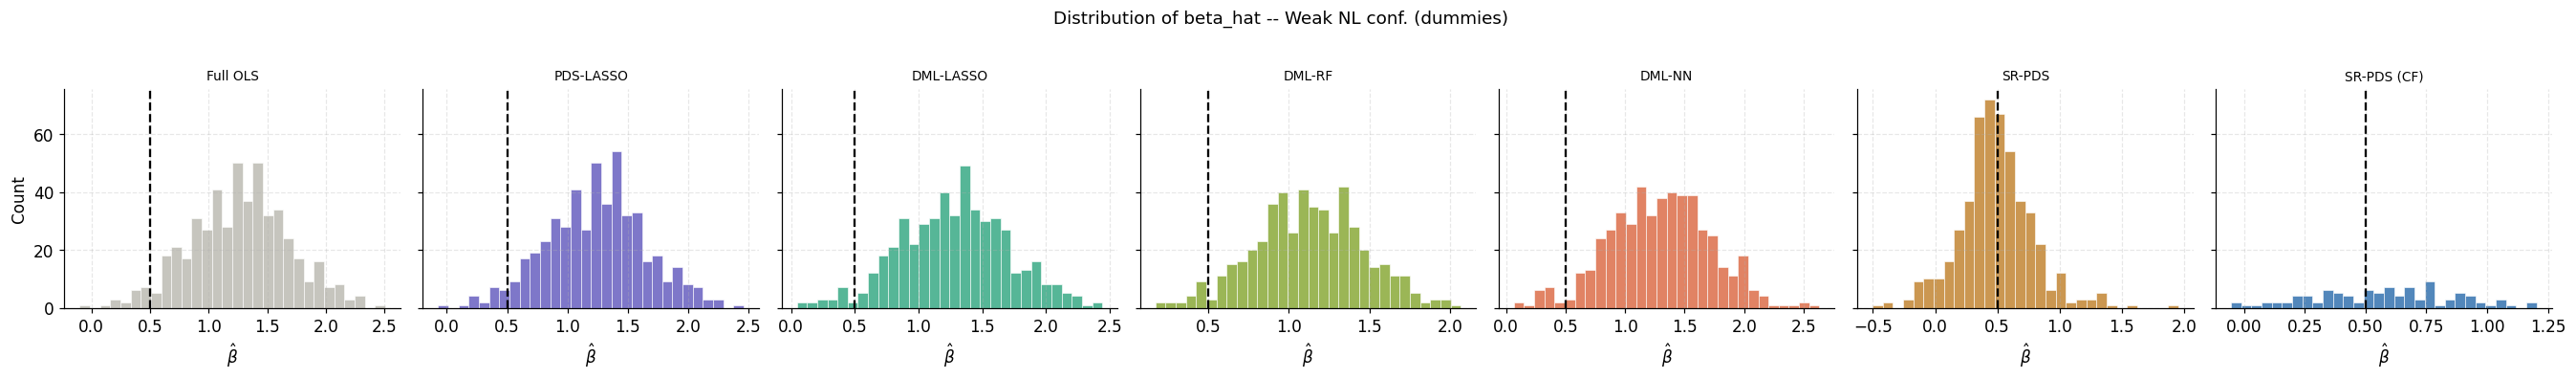

In [27]:
for dgp in ['dgp6', 'dgp7', 'dgp8']:
    plot_distributions(combined, beta0=0.5, dgp_key=dgp, save=True)
    plt.show()

  Saved: ../figures/recovery_vs_n.png


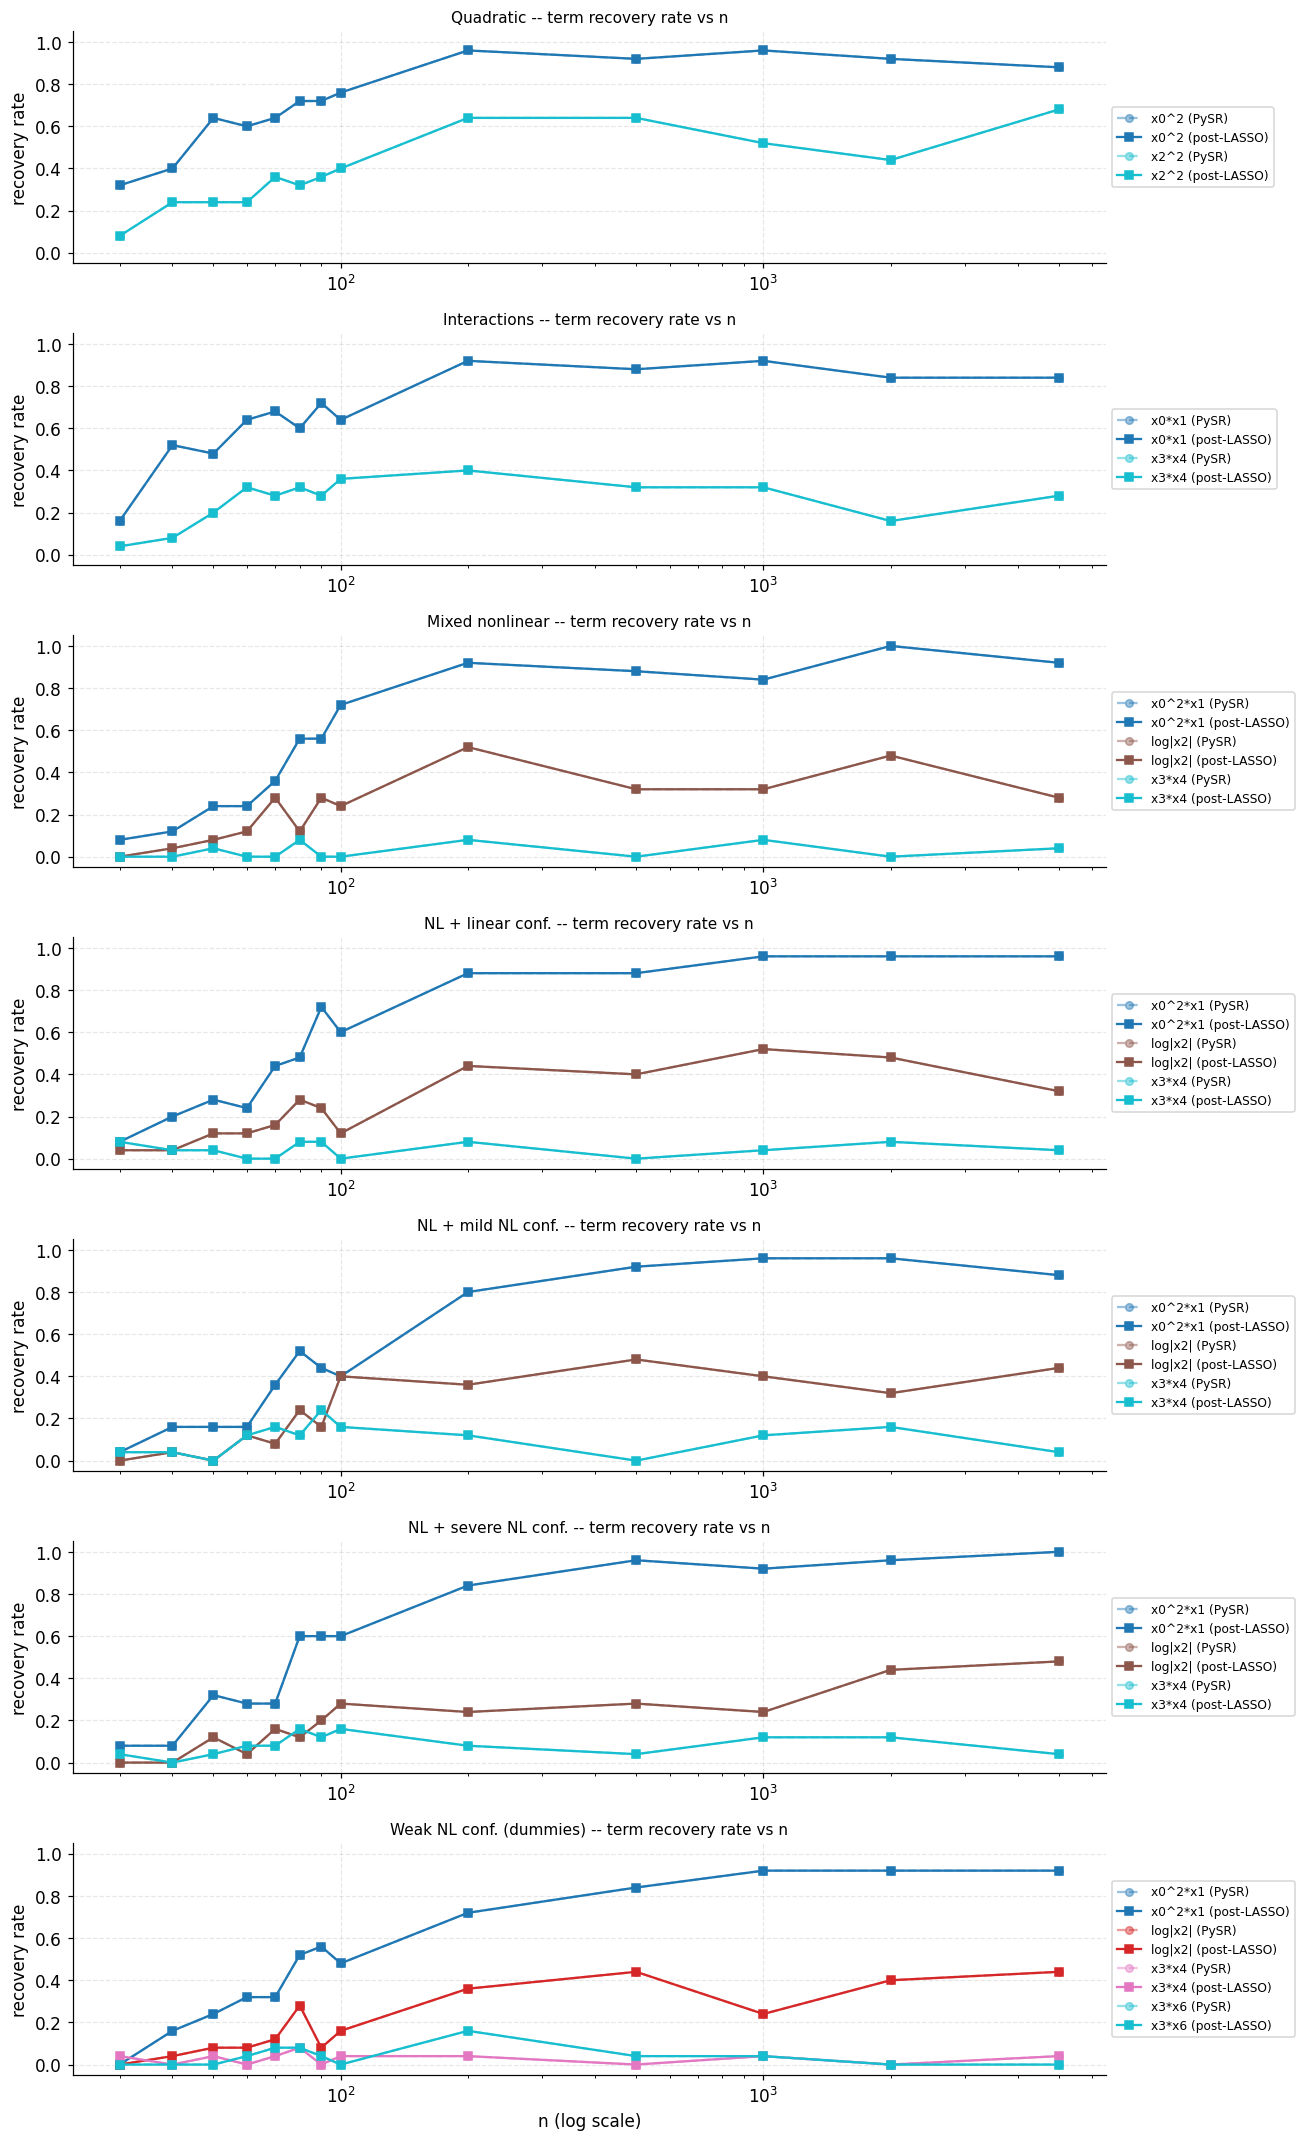

In [28]:
# This one needs the DGP registry — import from dgp.py
from dgp import DGP_REGISTRY  # or whatever it's called in your dgp.py
plot_recovery_vs_n(traj_df, DGP_REGISTRY, save=True)
plt.show()

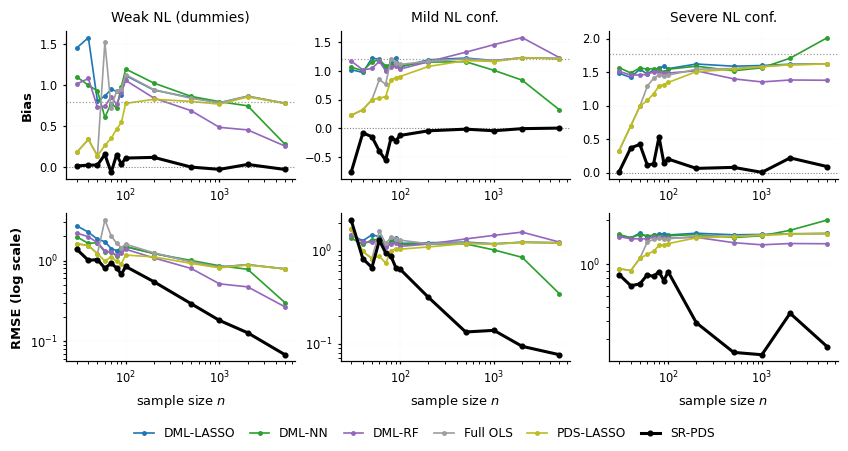

wrote figures/n_trajectory_confounding.png


In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- aggregate per-replication rows -> bias / rmse per (dgp, estimator, n) ---
d = traj_df[~traj_df["failed"].astype(bool)].copy()
d["err"] = d["beta_hat"] - d["beta0"]
agg = (d.groupby(["dgp", "est_label", "n_grid"], as_index=False)
         .agg(bias=("err", "mean"),
              rmse=("err", lambda e: np.sqrt(np.mean(e**2)))))

# column order: weak dummies -> mild -> severe : dgp code -> (title, analytical bias)
KEEP = {
    "dgp8": ("Weak NL (dummies)", 0.80),
    "dgp6": ("Mild NL conf.",     1.20),
    "dgp7": ("Severe NL conf.",   1.77),
}
COLORS = {"Full OLS": "#9e9e9e", "PDS-LASSO": "#bcbd22", "DML-LASSO": "#1f77b4",
          "DML-RF": "#9467bd", "DML-NN": "#2ca02c", "SR-PDS": "#000000"}

labels = list(agg["est_label"].unique())
is_sr = lambda l: "sr" in l.lower() and "pds" in l.lower()
methods = sorted(labels, key=lambda l: (is_sr(l), l))   # SR-PDS drawn last
cols = [c for c in KEEP if c in set(agg["dgp"])]

with plt.rc_context({"font.size": 8.5, "axes.titlesize": 9,
                     "axes.labelsize": 8.5, "legend.fontsize": 8,
                     "xtick.labelsize": 7.5, "ytick.labelsize": 7.5}):
    fig, axes = plt.subplots(2, len(cols), figsize=(7.6, 4.0),
                             squeeze=False, constrained_layout=True)
    for c, code in enumerate(cols):
        title, eb = KEEP[code]
        sub = agg[agg["dgp"] == code]
        ax_b, ax_r = axes[0, c], axes[1, c]
        for m in methods:
            dm = sub[sub["est_label"] == m].sort_values("n_grid")
            if dm.empty:
                continue
            hero = is_sr(m)
            st = dict(color=COLORS.get(m, "#777"), lw=2.0 if hero else 1.1,
                      marker="o", ms=3 if hero else 2.2, zorder=5 if hero else 2)
            ax_b.plot(dm["n_grid"], dm["bias"], label=m, **st)
            ax_r.plot(dm["n_grid"], dm["rmse"], label=m, **st)
        ax_b.axhline(0.0, ls=":", lw=0.7, color="0.5")
        if eb is not None:
            ax_b.axhline(eb, ls=":", lw=0.8, color="0.6")
        ax_b.set_title(title)                 # DGP name across the top
        for ax in (ax_b, ax_r):
            ax.set_xscale("log")
            ax.grid(True, which="major", ls="-", lw=0.3, color="0.9")
            ax.tick_params(length=2)
        ax_r.set_yscale("log")
        ax_r.set_xlabel("sample size $n$")
    axes[0, 0].set_ylabel("Bias", fontweight="bold")
    axes[1, 0].set_ylabel("RMSE (log scale)", fontweight="bold")

    handles, lbls = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, lbls, loc="outside lower center",
               ncol=len(methods), frameon=False, handlelength=1.6, columnspacing=1.2)

    os.makedirs("figures", exist_ok=True)
    fig.savefig("figures/n_trajectory_confounding.png", dpi=300, bbox_inches="tight")
    plt.show()
print("wrote figures/n_trajectory_confounding.png")

Following wont run unless full process has been complete

In [16]:
full_traj_df = pd.concat([traj_df, large_df], ignore_index=True)
full_traj_df.to_pickle(f'{RESULTS_DIR}/trajectory_full.pkl')
print(f"Full trajectory: {len(full_traj_df)} rows across "
      f"{full_traj_df['n_grid'].nunique()} n values")

NameError: name 'large_df' is not defined

In [15]:
plot_n_trajectory(full_traj_df, BETA0, save=True);          plt.show()
plot_recovery_vs_n(full_traj_df, DGP_REGISTRY, save=True); plt.show()

NameError: name 'full_traj_df' is not defined

## 7. Seed-robustness check

Run SR-PDS ten times on one fixed DGP-6 dataset (n=500) with different
PySR random seeds. Reports the discovered expression and beta_hat for
each seed. This backs up the reproducibility claim in the dissertation
- if every seed finds the same modal expression, seed-dependence is
weak in this regime.

In [1]:
seed_df = seed_robustness_check(
    dgp_fn   = DGP_REGISTRY['dgp6']['fn'],
    dgp_key  = 'dgp6',
    n        = 500, p=P, s=S, beta0=BETA0,
    data_seed   = 42,
    pysr_seeds  = list(range(1, N_REPS_SEEDS + 1)),
    save_dir = RESULTS_DIR,
)

print("\nSeed robustness summary:")
print(f"  beta_hat: mean={seed_df['beta_hat'].mean():.4f}  "
      f"std={seed_df['beta_hat'].std():.4f}  "
      f"min={seed_df['beta_hat'].min():.4f}  "
      f"max={seed_df['beta_hat'].max():.4f}")

# count how many seeds picked each distinct post-LASSO term set
term_counts = seed_df['post_lasso_terms_y'].value_counts()
print(f"\nDistinct post-LASSO y-term sets across {N_REPS_SEEDS} seeds:")
for terms, count in term_counts.items():
    print(f"  {count} seed(s): {terms}")

seed_df

NameError: name 'seed_robustness_check' is not defined

Extra section on a method where we expand the dictionary first

In [5]:
# === New baseline: PDS-LASSO on an explicit degree-2 basis =================
#  LASSO is linear only in the columns it is given. Hand it
# x augmented with all squares and pairwise interactions and it can represent
# the nonlinear confounders directly. This is the "build the basis by hand"
# rival to SR-PDS's automated discovery. Procedure is IDENTICAL to pds_lasso,
# only the design matrix differs, so we reuse pds_lasso() unchanged.

import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from estimators import pds_lasso

def _expand_poly2(X):
    Z = PolynomialFeatures(degree=2, interaction_only=False,
                           include_bias=False).fit_transform(X)
    Z = Z[:, Z.std(axis=0) > 1e-10]          # drop constant cols (dummy squares)
    Z = StandardScaler().fit_transform(Z)    # fair penalty across mixed scales
    return Z

def pds_lasso_poly2(X, d, y, n, p):
    Z = _expand_poly2(X)
    return pds_lasso(Z, d, y, n, Z.shape[1])

In [6]:
from dgp import DGP_REGISTRY

def get_dgp(name):
    entry = DGP_REGISTRY[name]
    if callable(entry):
        return entry
    if isinstance(entry, dict):
        for k in ('fn', 'func', 'function', 'dgp', 'generator', 'callable'):
            if k in entry and callable(entry[k]):
                return entry[k]
        for v in entry.values():
            if callable(v):
                return v
    raise TypeError(f"No callable in DGP_REGISTRY['{name}']: {entry!r}")

DGP_NAMES = list(DGP_REGISTRY.keys())
print("DGP keys:", DGP_NAMES)

dgp8 = get_dgp('dgp8')
X, d, y, b0 = dgp8(n=500, p=50, s=6, beta0=0.5, seed=0)
print("expanded columns:", _expand_poly2(X).shape[1])
print(pds_lasso_poly2(X, d, y, 500, 50))

DGP keys: ['dgp1', 'dgp2', 'dgp3', 'dgp4', 'dgp5', 'dgp6', 'dgp7', 'dgp8']
expanded columns: 1322
{'beta_hat': np.float64(-0.052993065015539256), 'se': np.float64(0.1795182572994499), 'ci_low': np.float64(-0.404848849322461), 'ci_high': np.float64(0.29886271929138253)}


In [9]:
import pandas as pd
from simulation import run_simulation
from evaluate import evaluate

N, P, S, BETA0, N_REP, BASE_SEED = 500, 50, 6, 0.5, 500, 0
rows = []
for name in DGP_NAMES:
    dgp_fn = get_dgp(name)
    res = run_simulation(dgp_fn, pds_lasso_poly2,
                         estimator_key='pds_poly2', dgp_key=name,
                         n=N, p=P, s=S, beta0=BETA0,
                         n_reps=N_REP, base_seed=BASE_SEED)
    m = evaluate(res, BETA0); m['dgp'] = name
    rows.append(m); print(name, m)
poly2_fixed = pd.DataFrame(rows).set_index('dgp')
poly2_fixed.to_csv('../results_full/pds_poly2_fixedn.csv')
poly2_fixed

reps:   0%|          | 0/500 [00:00<?, ?it/s]

dgp1 {'bias': np.float64(-0.0018), 'rmse': np.float64(0.0455), 'coverage': np.float64(0.944), 'size': np.float64(1.0), 'median': np.float64(0.5015), 'std': np.float64(0.0455), 'n_reps': 500, 'dgp': 'dgp1'}


dgp2 {'bias': np.float64(-0.0015), 'rmse': np.float64(0.0452), 'coverage': np.float64(0.952), 'size': np.float64(1.0), 'median': np.float64(0.4986), 'std': np.float64(0.0452), 'n_reps': 500, 'dgp': 'dgp2'}


dgp3 {'bias': np.float64(-0.001), 'rmse': np.float64(0.0452), 'coverage': np.float64(0.948), 'size': np.float64(1.0), 'median': np.float64(0.5005), 'std': np.float64(0.0452), 'n_reps': 500, 'dgp': 'dgp3'}


dgp4 {'bias': np.float64(-0.3727), 'rmse': np.float64(0.4287), 'coverage': np.float64(0.604), 'size': np.float64(0.076), 'median': np.float64(0.1206), 'std': np.float64(0.2121), 'n_reps': 500, 'dgp': 'dgp4'}


dgp5 {'bias': np.float64(-0.3793), 'rmse': np.float64(0.4385), 'coverage': np.float64(0.62), 'size': np.float64(0.066), 'median': np.float64(0.13), 'std': np.float64(0.2202), 'n_reps': 500, 'dgp': 'dgp5'}


dgp6 {'bias': np.float64(-0.3727), 'rmse': np.float64(0.4288), 'coverage': np.float64(0.602), 'size': np.float64(0.076), 'median': np.float64(0.1206), 'std': np.float64(0.2123), 'n_reps': 500, 'dgp': 'dgp6'}


dgp7 {'bias': np.float64(0.5476), 'rmse': np.float64(0.5719), 'coverage': np.float64(0.06), 'size': np.float64(1.0), 'median': np.float64(1.0511), 'std': np.float64(0.1651), 'n_reps': 500, 'dgp': 'dgp7'}


dgp8 {'bias': np.float64(-0.3993), 'rmse': np.float64(0.4544), 'coverage': np.float64(0.53), 'size': np.float64(0.078), 'median': np.float64(0.0911), 'std': np.float64(0.217), 'n_reps': 500, 'dgp': 'dgp8'}


,bias,rmse,coverage,size,median,std,n_reps
dgp,,,,,,,
dgp1,-0.0018,0.0455,0.944,1.000,0.5015,0.0455,500
dgp2,-0.0015,0.0452,0.952,1.000,0.4986,0.0452,500
dgp3,-0.0010,0.0452,0.948,1.000,0.5005,0.0452,500
dgp4,-0.3727,0.4287,0.604,0.076,0.1206,0.2121,500
dgp5,-0.3793,0.4385,0.620,0.066,0.1300,0.2202,500
dgp6,-0.3727,0.4288,0.602,0.076,0.1206,0.2123,500
dgp7,0.5476,0.5719,0.060,1.000,1.0511,0.1651,500
dgp8,-0.3993,0.4544,0.530,0.078,0.0911,0.2170,500


In [10]:
N_GRID   = [30, 50, 100, 200, 500, 1000, 2000, 5000, 10000]   # match your existing grid
TRAJ_REP = 25                                                 # match your trajectory n_rep
CONF_DGPS = ['dgp6', 'dgp7', 'dgp8']

traj_rows = []
for name in CONF_DGPS:
    dgp_fn = get_dgp(name)
    for n in N_GRID:
        res = run_simulation(dgp_fn, pds_lasso_poly2,
                             estimator_key='pds_poly2', dgp_key=name,
                             n=n, p=50, s=6, beta0=0.5,
                             n_reps=TRAJ_REP, base_seed=0)
        m = evaluate(res, 0.5); m.update({'dgp': name, 'n': n})
        traj_rows.append(m); print(name, n, round(m['bias'], 3), round(m['rmse'], 3))
poly2_traj = pd.DataFrame(traj_rows)
poly2_traj.to_csv('../results_full/pds_poly2_trajectory.csv', index=False)
poly2_traj

reps:   0%|          | 0/25 [00:00<?, ?it/s]/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: invalid value encountered in multiply
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: invalid value encountered in multiply
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/Users/przem

dgp6 30 -0.378 0.734


dgp6 50 -0.489 0.578


dgp6 100 -0.52 0.578


dgp6 200 -0.466 0.517


...

dgp8 1000 -0.245 0.306


dgp8 2000 -0.155 0.227


dgp8 5000 -0.053 0.123


dgp8 10000 -0.044 0.091


,bias,rmse,coverage,size,median,std,n_reps,dgp,n
0,-0.3777,0.7338,0.68,0.12,0.1748,0.6420,25,dgp6,30
1,-0.4891,0.5781,0.80,0.00,0.0296,0.3144,25,dgp6,50
2,-0.5204,0.5782,0.64,0.00,-0.0297,0.2571,25,dgp6,100
3,-0.4660,0.5171,0.52,0.04,0.0612,0.2289,25,dgp6,200
4,-0.3948,0.4571,0.64,0.08,0.1424,0.2350,25,dgp6,500
5,-0.3522,0.3899,0.68,0.12,0.1480,0.1709,25,dgp6,1000
6,-0.1450,0.2360,0.88,0.48,0.3195,0.1900,25,dgp6,2000
7,-0.0659,0.1328,0.96,1.00,0.4271,0.1177,25,dgp6,5000
8,-0.0165,0.0681,1.00,1.00,0.4763,0.0674,25,dgp6,10000
9,-0.0673,0.6155,0.48,0.00,0.4288,0.6244,25,dgp7,30


In [14]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from estimators import ESTIMATOR_REGISTRY

pds_lasso = ESTIMATOR_REGISTRY['pds_lasso']['fn']    # the real PDS, reused verbatim

def _expand_poly2(X):
    Z = PolynomialFeatures(degree=2, interaction_only=False,
                           include_bias=False).fit_transform(X)
    Z = Z[:, Z.std(axis=0) > 1e-10]          # drop constant cols (dummy squares in dgp8)
    Z = StandardScaler().fit_transform(Z)
    return Z

def pds_lasso_poly2(X, d, y, n, p):
    Z = _expand_poly2(X)
    return pds_lasso(Z, d, y, n, Z.shape[1])

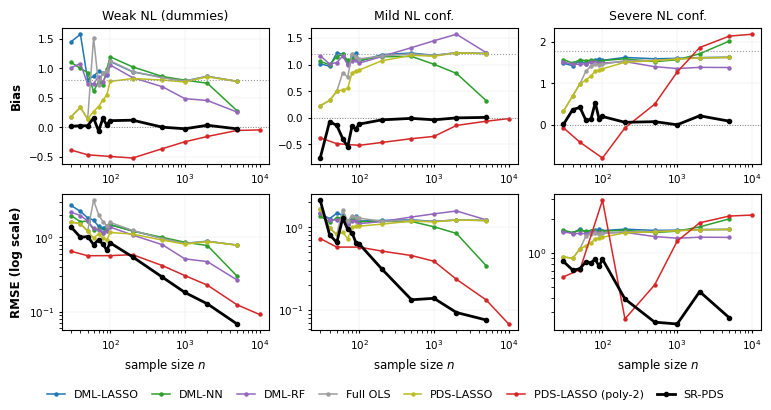

wrote figures/n_trajectory_confounding.png


In [16]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

RESULTS_DIR = '../results_full'

# --- 1. existing replication-level trajectory (all methods except poly-2) ---
for cand in ('trajectory_full.pkl', 'trajectory.pkl'):
    path = os.path.join(RESULTS_DIR, cand)
    if os.path.exists(path):
        traj_rep = pd.read_pickle(path); break
else:
    traj_rep = full_traj_df if 'full_traj_df' in globals() else traj_df   # in-memory fallback

d = traj_rep[~traj_rep['failed'].astype(bool)].copy()
d['err'] = d['beta_hat'] - d['beta0']
agg = (d.groupby(['dgp', 'est_label', 'n_grid'], as_index=False)
         .agg(bias=('err', 'mean'),
              rmse=('err', lambda e: np.sqrt(np.mean(e ** 2)))))

# --- 2. poly-2 baseline (already aggregated by evaluate() in Cell 4) ---------
if 'poly2_traj' in globals():
    p2 = poly2_traj.copy()
else:
    p2 = pd.read_csv(os.path.join(RESULTS_DIR, 'pds_poly2_trajectory.csv'))
p2 = (p2.rename(columns={'n': 'n_grid'})
        [['dgp', 'n_grid', 'bias', 'rmse']]
        .assign(est_label='PDS-LASSO (poly-2)'))

agg = pd.concat([agg, p2], ignore_index=True)

# --- 3. plot: identical style to Figure 1, poly-2 added in red ---------------
KEEP = {'dgp8': ('Weak NL (dummies)', 0.80),
        'dgp6': ('Mild NL conf.',     1.20),
        'dgp7': ('Severe NL conf.',   1.77)}
COLORS = {'Full OLS': '#9e9e9e', 'PDS-LASSO': '#bcbd22', 'DML-LASSO': '#1f77b4',
          'DML-RF': '#9467bd', 'DML-NN': '#2ca02c', 'SR-PDS': '#000000',
          'PDS-LASSO (poly-2)': '#d62728'}          # new brute-force baseline

is_sr   = lambda l: 'sr' in l.lower() and 'pds' in l.lower()
labels  = list(agg['est_label'].unique())
methods = sorted(labels, key=lambda l: (is_sr(l), l))   # SR-PDS drawn last (on top)
cols    = [c for c in KEEP if c in set(agg['dgp'])]

with plt.rc_context({'font.size': 8.5, 'axes.titlesize': 9, 'axes.labelsize': 8.5,
                     'legend.fontsize': 8, 'xtick.labelsize': 7.5, 'ytick.labelsize': 7.5}):
    fig, axes = plt.subplots(2, len(cols), figsize=(7.6, 4.0),
                             squeeze=False, constrained_layout=True)
    for c, code in enumerate(cols):
        title, eb = KEEP[code]
        sub = agg[agg['dgp'] == code]
        ax_b, ax_r = axes[0, c], axes[1, c]
        for m in methods:
            dm = sub[sub['est_label'] == m].sort_values('n_grid')
            if dm.empty:
                continue
            hero = is_sr(m)
            st = dict(color=COLORS.get(m, '#777'), lw=2.0 if hero else 1.1,
                      marker='o', ms=3 if hero else 2.2, zorder=5 if hero else 2)
            ax_b.plot(dm['n_grid'], dm['bias'], label=m, **st)
            ax_r.plot(dm['n_grid'], dm['rmse'], label=m, **st)
        ax_b.axhline(0.0, ls=':', lw=0.7, color='0.5')
        if eb is not None:
            ax_b.axhline(eb, ls=':', lw=0.8, color='0.6')
        ax_b.set_title(title)
        for ax in (ax_b, ax_r):
            ax.set_xscale('log')
            ax.grid(True, which='major', ls='-', lw=0.3, color='0.9')
            ax.tick_params(length=2)
        ax_r.set_yscale('log')
        ax_r.set_xlabel('sample size $n$')
    axes[0, 0].set_ylabel('Bias', fontweight='bold')
    axes[1, 0].set_ylabel('RMSE (log scale)', fontweight='bold')
    handles, lbls = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, lbls, loc='outside lower center',
               ncol=len(methods), frameon=False, handlelength=1.6, columnspacing=1.2)
    os.makedirs('figures', exist_ok=True)
    fig.savefig('figures/n_trajectory_confounding.png', dpi=300, bbox_inches='tight')
    plt.show()
print('wrote figures/n_trajectory_confounding.png')

Building out a three polynomial dictionary

In [17]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from estimators import ESTIMATOR_REGISTRY

pds_lasso = ESTIMATOR_REGISTRY['pds_lasso']['fn']     # reuse the real PDS verbatim

def _expand_polyk(X, degree):
    Z = PolynomialFeatures(degree=degree, interaction_only=False,
                           include_bias=False).fit_transform(X)
    Z = Z[:, Z.std(axis=0) > 1e-10]      # drop constant cols (dummy^2 = 1 in dgp8)
    Z = StandardScaler().fit_transform(Z) # fair penalty across mixed-scale columns
    return Z

def pds_lasso_poly3(X, d, y, n, p):
    """PDS-LASSO on the full degree-3 basis: ~23,425 columns at p=50."""
    Z = _expand_polyk(X, 3)
    return pds_lasso(Z, d, y, n, Z.shape[1])

In [20]:
import time, pandas as pd
from simulation import run_simulation
from evaluate import evaluate
from dgp import DGP_REGISTRY

POLY3_GRID = [30, 50, 100, 200, 500, 1000, 2000, 5000, 10000]   # capped: a 2000x23425 matrix is ~0.4GB.
                                                   # raise the top to 5000 only if you have RAM;
                                                   # avoid 10000 (design matrix ~3.7GB).
POLY3_REP  = 25
CONF_DGPS  = ['dgp6', 'dgp7', 'dgp8']              # mild / severe / weak

rows, t0 = [], time.time()
for name in CONF_DGPS:
    fn = DGP_REGISTRY[name]['fn']
    for n in POLY3_GRID:
        res = run_simulation(fn, pds_lasso_poly3, estimator_key='pds_poly3',
                             dgp_key=name, n=n, p=50, s=6, beta0=0.5,
                             n_reps=POLY3_REP, n_jobs=1, base_seed=0)   # n_jobs=1: each fit is RAM-heavy
        m = evaluate(res, 0.5); m.update({'dgp': name, 'n': n})
        rows.append(m)
        print(f"[{(time.time()-t0)/60:5.1f}m] {name} n={n:>5}  "
              f"bias={m['bias']:+.3f}  rmse={m['rmse']:.3f}  fail={int(res['failed'].sum())}")
poly3_traj = pd.DataFrame(rows)
poly3_traj.to_csv('../results_full/pds_poly3_trajectory.csv', index=False)
poly3_traj

reps:  16%|█▌        | 4/25 [00:00<00:01, 11.23it/s]/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
reps:  48%|████▊     | 12/25 [00:01<00:01, 10.16it/s]/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: invalid value encountered in multiply
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
reps:  84%|████████▍ | 21/25 [00:02<00:00,  8.15it/s]/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning

[  0.0m] dgp6 n=   30  bias=-0.310  rmse=1.068  fail=0


[  0.1m] dgp6 n=   50  bias=-0.433  rmse=0.505  fail=0


[  0.1m] dgp6 n=  100  bias=-0.442  rmse=0.500  fail=0


[  0.2m] dgp6 n=  200  bias=-0.452  rmse=0.472  fail=0


...

[ 55.6m] dgp8 n= 1000  bias=-0.426  rmse=0.435  fail=0


[ 56.5m] dgp8 n= 2000  bias=-0.378  rmse=0.382  fail=0


[ 59.9m] dgp8 n= 5000  bias=-0.322  rmse=0.326  fail=0


[ 70.3m] dgp8 n=10000  bias=-0.266  rmse=0.269  fail=0


,bias,rmse,coverage,size,median,std,n_reps,dgp,n
0,-0.3097,1.0681,0.64,0.04,0.0123,1.0433,25,dgp6,30
1,-0.4334,0.5051,0.64,0.00,0.0627,0.2648,25,dgp6,50
2,-0.4424,0.4997,0.40,0.12,0.0415,0.2370,25,dgp6,100
3,-0.4515,0.4716,0.12,0.04,0.0446,0.1391,25,dgp6,200
4,-0.4281,0.4455,0.04,0.24,0.0668,0.1256,25,dgp6,500
5,-0.4051,0.4112,0.00,0.20,0.0888,0.0719,25,dgp6,1000
6,-0.3699,0.3768,0.00,0.48,0.1223,0.0733,25,dgp6,2000
7,-0.3261,0.3311,0.00,0.92,0.1854,0.0584,25,dgp6,5000
8,-0.2471,0.2496,0.00,1.00,0.2559,0.0360,25,dgp6,10000
9,-0.4853,1.7434,0.80,0.00,0.3212,1.7091,25,dgp7,30


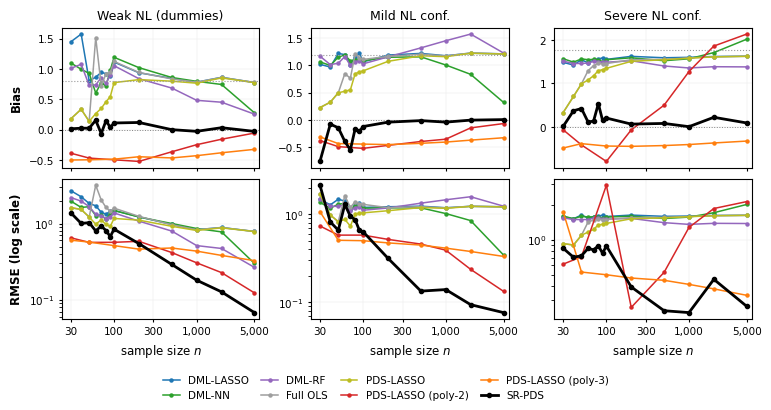

wrote figures/n_trajectory_confounding.png  (capped at n = 5000 )


In [27]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator
RESULTS_DIR = '../results_full'
NMAX = 5000                      # common max across all methods -> consistent right edge

# --- OG methods: replication-level trajectory ------------------------------
traj_rep = pd.read_pickle(os.path.join(RESULTS_DIR, 'trajectory.pkl'))
d = traj_rep[~traj_rep['failed'].astype(bool)].copy()
d['err'] = d['beta_hat'] - d['beta0']
agg = (d.groupby(['dgp', 'est_label', 'n_grid'], as_index=False)
         .agg(bias=('err', 'mean'), rmse=('err', lambda e: np.sqrt(np.mean(e**2)))))

# --- poly baselines: aggregated CSVs ---------------------------------------
def _poly_agg(path, label):
    df = pd.read_csv(path).rename(columns={'n': 'n_grid'})
    return df[['dgp', 'n_grid', 'bias', 'rmse']].assign(est_label=label)

extra = []
for fn, lbl in [('pds_poly2_trajectory.csv', 'PDS-LASSO (poly-2)'),
                ('pds_poly3_trajectory.csv', 'PDS-LASSO (poly-3)')]:
    p = os.path.join(RESULTS_DIR, fn)
    if os.path.exists(p):
        extra.append(_poly_agg(p, lbl))
agg = pd.concat([agg, *extra], ignore_index=True)

# --- cap everything at NMAX so the lines end consistently ------------------
agg = agg[agg['n_grid'] <= NMAX]

# --- plot (Figure 1 style) -------------------------------------------------
KEEP = {'dgp8': ('Weak NL (dummies)', 0.80),
        'dgp6': ('Mild NL conf.',     1.20),
        'dgp7': ('Severe NL conf.',   1.77)}
COLORS = {'Full OLS': '#9e9e9e', 'PDS-LASSO': '#bcbd22', 'DML-LASSO': '#1f77b4',
          'DML-RF': '#9467bd', 'DML-NN': '#2ca02c', 'SR-PDS': '#000000',
          'PDS-LASSO (poly-2)': '#d62728', 'PDS-LASSO (poly-3)': '#ff7f0e'}

NTICKS = [30, 100, 300, 1000, 5000]
def _fmt(v): return f'{v:,}'

is_sr   = lambda l: 'sr' in l.lower() and 'pds' in l.lower()
methods = sorted(agg['est_label'].unique(), key=lambda l: (is_sr(l), l))   # SR-PDS on top
cols    = [c for c in KEEP if c in set(agg['dgp'])]

with plt.rc_context({'font.size': 8.5, 'axes.titlesize': 9, 'axes.labelsize': 8.5,
                     'legend.fontsize': 7.5, 'xtick.labelsize': 7.5, 'ytick.labelsize': 7.5}):
    fig, axes = plt.subplots(2, len(cols), figsize=(7.6, 4.0),
                             squeeze=False, constrained_layout=True)
    for c, code in enumerate(cols):
        title, eb = KEEP[code]; sub = agg[agg['dgp'] == code]
        ax_b, ax_r = axes[0, c], axes[1, c]
        for m in methods:
            dm = sub[sub['est_label'] == m].sort_values('n_grid')
            if dm.empty: continue
            hero = is_sr(m)
            st = dict(color=COLORS.get(m, '#777'), lw=2.0 if hero else 1.1,
                      marker='o', ms=3 if hero else 2.2, zorder=5 if hero else 2)
            ax_b.plot(dm['n_grid'], dm['bias'], label=m, **st)
            ax_r.plot(dm['n_grid'], dm['rmse'], label=m, **st)
        ax_b.axhline(0.0, ls=':', lw=0.7, color='0.5')
        if eb is not None: ax_b.axhline(eb, ls=':', lw=0.8, color='0.6')
        ax_b.set_title(title)
        for ax in (ax_b, ax_r):
            ax.set_xscale('log')
            ax.set_xlim(right=NMAX * 1.15)                 # pad so 5,000 isn't on the frame
            ax.xaxis.set_major_locator(FixedLocator(NTICKS))
            ax.xaxis.set_major_formatter(FixedFormatter([_fmt(v) for v in NTICKS]))
            ax.xaxis.set_minor_locator(NullLocator())      # drop 2x10^3-style minor ticks
            ax.grid(True, which='major', ls='-', lw=0.3, color='0.9')
            ax.tick_params(length=2)
        ax_b.tick_params(labelbottom=False)                # x numerals on bottom row only
        ax_r.set_yscale('log')
        ax_r.set_xlabel('sample size $n$')
    axes[0, 0].set_ylabel('Bias', fontweight='bold')
    axes[1, 0].set_ylabel('RMSE (log scale)', fontweight='bold')
    handles, lbls = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, lbls, loc='outside lower center',
               ncol=4, frameon=False, handlelength=1.6, columnspacing=1.2)
    os.makedirs('figures', exist_ok=True)
    fig.savefig('figures/n_trajectory_confounding.png', dpi=300, bbox_inches='tight')
    plt.show()
print('wrote figures/n_trajectory_confounding.png  (capped at n =', NMAX, ')')

loaded OG rows: 15675 | n values: [np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100), np.int64(200), np.int64(500), np.int64(1000), np.int64(2000), np.int64(5000), np.int64(10000)]


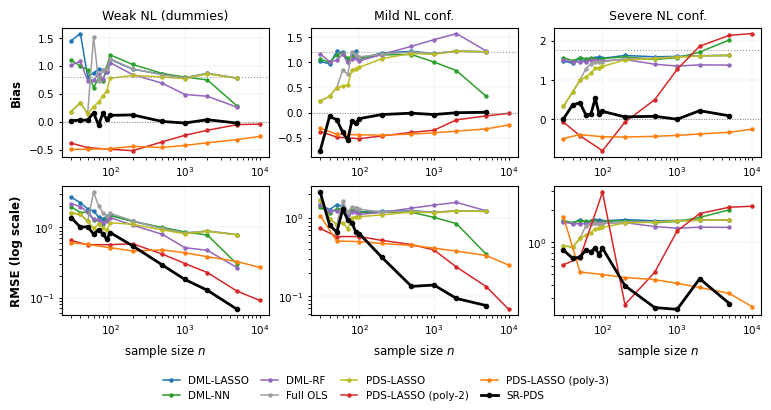

wrote figures/n_trajectory_confounding_poly23.png


In [24]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
RESULTS_DIR = '../results_full'

# --- existing replication-level results for the OG methods ------------------
# Prefer the combined trajectory+large-n file (Cell 33). If it isn't there,
# stitch the trajectory and the separately-saved large-n (n=10,000) results.
frames = []
combined_path = os.path.join(RESULTS_DIR, 'trajectory_full.pkl')
if os.path.exists(combined_path):
    frames.append(pd.read_pickle(combined_path))
else:
    for cand in ('trajectory.pkl', 'large_n.pkl'):
        p = os.path.join(RESULTS_DIR, cand)
        if os.path.exists(p):
            frames.append(pd.read_pickle(p))
    # in-memory fallback if nothing on disk
    if not frames:
        if 'full_traj_df' in globals():
            frames.append(full_traj_df)
        else:
            if 'traj_df'  in globals(): frames.append(traj_df)
            if 'large_df' in globals(): frames.append(large_df)

traj_rep = pd.concat(frames, ignore_index=True)
# de-dup in case trajectory and large-n overlap on any (dgp, est, n, seed)
key = [c for c in ('dgp', 'est_label', 'n_grid', 'seed') if c in traj_rep.columns]
traj_rep = traj_rep.drop_duplicates(subset=key)
print("loaded OG rows:", len(traj_rep),
      "| n values:", sorted(traj_rep['n_grid'].unique()))

d = traj_rep[~traj_rep['failed'].astype(bool)].copy()
d['err'] = d['beta_hat'] - d['beta0']
agg = (d.groupby(['dgp', 'est_label', 'n_grid'], as_index=False)
         .agg(bias=('err', 'mean'), rmse=('err', lambda e: np.sqrt(np.mean(e**2)))))

# --- poly baselines (aggregated CSVs / in-memory) ---------------------------
def _poly_agg(df_or_csv, label):
    df = df_or_csv if isinstance(df_or_csv, pd.DataFrame) else pd.read_csv(df_or_csv)
    return (df.rename(columns={'n': 'n_grid'})[['dgp', 'n_grid', 'bias', 'rmse']]
              .assign(est_label=label))

extra = []
if 'poly2_traj' in globals():
    extra.append(_poly_agg(poly2_traj, 'PDS-LASSO (poly-2)'))
elif os.path.exists(f'{RESULTS_DIR}/pds_poly2_trajectory.csv'):
    extra.append(_poly_agg(f'{RESULTS_DIR}/pds_poly2_trajectory.csv', 'PDS-LASSO (poly-2)'))
if 'poly3_traj' in globals():
    extra.append(_poly_agg(poly3_traj, 'PDS-LASSO (poly-3)'))
elif os.path.exists(f'{RESULTS_DIR}/pds_poly3_trajectory.csv'):
    extra.append(_poly_agg(f'{RESULTS_DIR}/pds_poly3_trajectory.csv', 'PDS-LASSO (poly-3)'))
agg = pd.concat([agg, *extra], ignore_index=True)

# --- plot (Figure 1 style) --------------------------------------------------
KEEP = {'dgp8': ('Weak NL (dummies)', 0.80),
        'dgp6': ('Mild NL conf.',     1.20),
        'dgp7': ('Severe NL conf.',   1.77)}
COLORS = {'Full OLS': '#9e9e9e', 'PDS-LASSO': '#bcbd22', 'DML-LASSO': '#1f77b4',
          'DML-RF': '#9467bd', 'DML-NN': '#2ca02c', 'SR-PDS': '#000000',
          'PDS-LASSO (poly-2)': '#d62728', 'PDS-LASSO (poly-3)': '#ff7f0e'}

is_sr   = lambda l: 'sr' in l.lower() and 'pds' in l.lower()
methods = sorted(agg['est_label'].unique(), key=lambda l: (is_sr(l), l))  # SR-PDS last/on top
cols    = [c for c in KEEP if c in set(agg['dgp'])]

with plt.rc_context({'font.size': 8.5, 'axes.titlesize': 9, 'axes.labelsize': 8.5,
                     'legend.fontsize': 7.5, 'xtick.labelsize': 7.5, 'ytick.labelsize': 7.5}):
    fig, axes = plt.subplots(2, len(cols), figsize=(7.6, 4.0),
                             squeeze=False, constrained_layout=True)
    for c, code in enumerate(cols):
        title, eb = KEEP[code]; sub = agg[agg['dgp'] == code]
        ax_b, ax_r = axes[0, c], axes[1, c]
        for m in methods:
            dm = sub[sub['est_label'] == m].sort_values('n_grid')
            if dm.empty: continue
            hero = is_sr(m)
            st = dict(color=COLORS.get(m, '#777'), lw=2.0 if hero else 1.1,
                      marker='o', ms=3 if hero else 2.2, zorder=5 if hero else 2)
            ax_b.plot(dm['n_grid'], dm['bias'], label=m, **st)
            ax_r.plot(dm['n_grid'], dm['rmse'], label=m, **st)
        ax_b.axhline(0.0, ls=':', lw=0.7, color='0.5')
        if eb is not None: ax_b.axhline(eb, ls=':', lw=0.8, color='0.6')
        ax_b.set_title(title)
        for ax in (ax_b, ax_r):
            ax.set_xscale('log'); ax.grid(True, which='major', ls='-', lw=0.3, color='0.9')
            ax.tick_params(length=2)
        ax_r.set_yscale('log'); ax_r.set_xlabel('sample size $n$')
    axes[0, 0].set_ylabel('Bias', fontweight='bold')
    axes[1, 0].set_ylabel('RMSE (log scale)', fontweight='bold')
    handles, lbls = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, lbls, loc='outside lower center',
               ncol=4, frameon=False, handlelength=1.6, columnspacing=1.2)
    os.makedirs('figures', exist_ok=True)
    fig.savefig('figures/n_trajectory_confounding_poly23.png', dpi=300, bbox_inches='tight')
    plt.show()
print('wrote figures/n_trajectory_confounding_poly23.png')

## 8. Summary and save

In [ ]:
tag = datetime.datetime.now().strftime('%Y%m%d_%H%M')
print(f"Run tag: {tag}\n")
print(f"Files in {RESULTS_DIR}:")
for f in sorted(os.listdir(RESULTS_DIR)):
    size_mb = os.path.getsize(f'{RESULTS_DIR}/{f}') / 1024 ** 2
    print(f"  {f:<40}  {size_mb:>7.2f} MB")

In [ ]:
print('=' * 70)
print(f"  SR-PDS simulation study - full results ({tag})")
print('=' * 70)
print(f"\n  Headline:   {N_REPS_MAIN} reps x {len(DGP_KEYS)} DGPs x "
      f"{len(EST_KEYS)} methods at n={N_HEADLINE}")
print(f"               (sr_pds_cf reduced to {N_REPS_CF} reps)")
print(f"  Trajectory: {N_REPS_TRAJ} reps x {len(DGP_KEYS)} DGPs x "
      f"{len(TRAJ_EST_KEYS)} methods at {len(N_GRID_TRAJ)} n values")
print(f"  Large-n:    {N_REPS_TRAJ} reps at n=10,000 (4 DGPs) and "
      f"n=50,000 (3 DGPs)")
print(f"  Seeds:      {N_REPS_SEEDS} PySR seeds on DGP-6 at n={N_HEADLINE}")
print(f"\n  Output:     {RESULTS_DIR}/")
print('=' * 70)